# 🧠 Notebook 03 — Sentiment Analysis & User Satisfaction Intelligence
## SentimentCompass: Understanding User Satisfaction, Topic Trends, and Migration Signals

---

**Project:** SentimentCompass  
**Input:** `data/processed/reviews_clean.parquet`  
**Output:** `data/processed/reviews_sentiment.parquet` + `reviews_sentiment.csv`  
**Purpose:** Core analytical notebook — compute multi-model sentiment scores, build the Thumbs-Weighted Sentiment Index (TWSI), and produce platform-level satisfaction intelligence.

### 🎯 What this notebook does

| # | Step | Method | Rows covered |
|---|------|--------|-------------|
| 1 | VADER sentiment scoring | Rule-based lexicon | All 50,000 |
| 2 | TextBlob polarity + subjectivity | Rule-based + NaïveBayes | All 50,000 |
| 3 | RoBERTa transformer sentiment | `cardiffnlp/twitter-roberta-base-sentiment-latest` | All (GPU) / 10K sample (CPU) |
| 4 | Model comparison & agreement | Pearson r + Cohen's κ | Processed subset |
| 5 | TWSI computation | Thumbs-weighted formula | All 50,000 (VADER) |
| 6 | Platform satisfaction ranking | Composite metrics | 5 platforms |
| 7 | Visualisations (7 charts) | matplotlib / seaborn | — |

> ⚠️ **Runtime note:** VADER + TextBlob run on the full 50K (~5 min total).  
> RoBERTa auto-selects strategy: GPU → full 50K (~15 min) · CPU → stratified 10K sample (~30 min).  
> TWSI_vader uses all 50K rows and is the primary satisfaction index regardless of mode.

---
## ⚙️ Section 1 — Setup & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, time, warnings
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Lexical sentiment ─────────────────────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats
from sklearn.metrics import cohen_kappa_score

# ── Display ───────────────────────────────────────────────────────────────────
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "grid.color"        : "#E8E8E8",
    "grid.linewidth"    : 0.8,
    "legend.fontsize"   : 9,
    "legend.framealpha" : 0.92,
})

# ── Platform palette ──────────────────────────────────────────────────────────
APP_COLORS = {
    "ChatGPT"           : "#1D9E75",
    "Google_Gemini"     : "#378ADD",
    "Claude"            : "#534AB7",
    "Microsoft_Copilot" : "#BA7517",
    "Perplexity"        : "#D85A30",
}
APP_ORDER  = ["ChatGPT", "Google_Gemini", "Claude", "Microsoft_Copilot", "Perplexity"]
APP_LABELS = {
    "ChatGPT"           : "ChatGPT",
    "Google_Gemini"     : "Gemini",
    "Claude"            : "Claude",
    "Microsoft_Copilot" : "MS Copilot",
    "Perplexity"        : "Perplexity",
}
PALETTE     = [APP_COLORS[a] for a in APP_ORDER]
CAT_COLORS  = {"Positive": "#1D9E75", "Neutral": "#F5C518", "Negative": "#E24B4A"}

# ── Sentiment label thresholds ────────────────────────────────────────────────
# VADER: standard thresholds (Hutto & Gilbert, 2014)
VADER_POS_THRESH = 0.05
VADER_NEG_THRESH = -0.05

# TextBlob: slightly wider neutral band for short texts
TB_POS_THRESH = 0.10
TB_NEG_THRESH = -0.10

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed/"
FIGURES_DIR   = "../outputs/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

INPUT_PATH    = os.path.join(PROCESSED_DIR, "reviews_clean.parquet")
OUTPUT_PARQ   = os.path.join(PROCESSED_DIR, "reviews_sentiment.parquet")
OUTPUT_CSV    = os.path.join(PROCESSED_DIR, "reviews_sentiment.csv")

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  📁  Saved → {path}")

print("✅  Setup complete.")
print(f"    Figures  : {os.path.abspath(FIGURES_DIR)}")
print(f"    Input    : {INPUT_PATH}")

✅  Setup complete.
    Figures  : C:\Users\admin\Desktop\VS CODE\AI-Platform-Sentiment-and-Migration-Analysis\outputs\figures
    Input    : ../data/processed/reviews_clean.parquet


---
## 📂 Section 2 — Load Processed Dataset

We load the master cleaned dataset produced by Notebook 02. The key columns we need are `review_text_clean` (for sentiment scoring) and `thumbs_log` (for TWSI weighting).

In [2]:
df = pd.read_parquet(INPUT_PATH)

print("=" * 60)
print("  DATASET LOADED")
print("=" * 60)
print(f"  Rows       : {df.shape[0]:>10,}")
print(f"  Columns    : {df.shape[1]:>10}")
print(f"  Memory     : {df.memory_usage(deep=True).sum()/1e6:>9.2f} MB")
print("=" * 60)
print()

# Verify required columns are present
required = ["review_text_clean", "Thumbs_Up_Count", "thumbs_log",
            "Star_Rating", "App", "Review_Date",
            "is_positive_review", "is_negative_review"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    print(f"⚠   Missing columns from NB02: {missing_cols}")
    print("    Please run Notebook 02 first.")
else:
    print("✅  All required columns from Notebook 02 are present.")

print()
print("First 3 reviews (review_text_clean):")
for i, row in df.head(3).iterrows():
    print(f"  [{APP_LABELS[row['App']]}] ★{row['Star_Rating']}  "
          f"\"{str(row['review_text_clean'])[:90]}\"")

  DATASET LOADED
  Rows       :     50,000
  Columns    :         30
  Memory     :     32.67 MB

✅  All required columns from Notebook 02 are present.

First 3 reviews (review_text_clean):
  [ChatGPT] ★5  "I am loving it. I knowa lot of things now easy way. I dont use google any more."
  [ChatGPT] ★5  "i love this app its very nice and super duper app"
  [ChatGPT] ★1  "THIS APP SUCKS THIS SHOULD NEVER EXIST ITS LITERRY MESSING WITH ME WHY DOSE THIS EXIST?!?!"


---
## 📘 Section 3 — VADER Sentiment Analysis

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based lexicon specifically tuned for social media and short texts. It is fast (~50K reviews in under a minute), requires no training, and handles:
- Capitalization (`GREAT` scores higher than `great`)
- Punctuation emphasis (`great!!!` > `great`)
- Negation (`not good` correctly scores negative)
- Degree modifiers (`very good` > `good`)

**Output columns:**
| Column | Range | Description |
|--------|-------|-------------|
| `vader_compound` | [−1, 1] | Overall sentiment score — primary metric |
| `vader_positive` | [0, 1] | Proportion of positive sentiment |
| `vader_negative` | [0, 1] | Proportion of negative sentiment |
| `vader_neutral` | [0, 1] | Proportion of neutral sentiment |
| `vader_label` | Pos/Neg/Neu | Label from compound threshold (±0.05) |

> Note: positive + negative + neutral = 1.0 always.

In [3]:
_vader = SentimentIntensityAnalyzer()

def run_vader(text):
    if not isinstance(text, str) or not text.strip():
        return {"compound": 0.0, "pos": 0.0, "neg": 0.0, "neu": 1.0}
    return _vader.polarity_scores(str(text))

def vader_label(compound):
    if compound >= VADER_POS_THRESH:
        return "Positive"
    elif compound <= VADER_NEG_THRESH:
        return "Negative"
    return "Neutral"

# ── Apply to all 50K reviews ──────────────────────────────────────────────────
print("Running VADER on all 50,000 reviews...")
_t0 = time.time()

_vader_scores = df["review_text_clean"].apply(run_vader)

df["vader_compound"] = _vader_scores.apply(lambda x: round(x["compound"], 4))
df["vader_positive"] = _vader_scores.apply(lambda x: round(x["pos"],      4))
df["vader_negative"] = _vader_scores.apply(lambda x: round(x["neg"],      4))
df["vader_neutral"]  = _vader_scores.apply(lambda x: round(x["neu"],      4))
df["vader_label"]    = df["vader_compound"].apply(vader_label)

print(f"✅  Done in {time.time()-_t0:.1f}s")
print()

# ── Summary ───────────────────────────────────────────────────────────────────
print("VADER label distribution (all 50K):")
vc = df["vader_label"].value_counts()
for label in ["Positive", "Neutral", "Negative"]:
    n = vc.get(label, 0)
    print(f"  {label:<10} : {n:>7,}  ({n/len(df)*100:.1f}%)")

print()
print("VADER compound score statistics by platform:")
vader_stats = (df.groupby("App")["vader_compound"]
                 .agg(["mean","median","std"])
                 .round(4)
                 .reindex(APP_ORDER)
                 .rename(index=APP_LABELS))
print(vader_stats.to_string())

Running VADER on all 50,000 reviews...
✅  Done in 6.5s

VADER label distribution (all 50K):
  Positive   :  34,874  (69.7%)
  Neutral    :   5,465  (10.9%)
  Negative   :   9,661  (19.3%)

VADER compound score statistics by platform:
             mean  median    std
App                             
ChatGPT    0.3778  0.5719 0.5205
Gemini     0.2974  0.4404 0.5342
Claude     0.3763  0.5719 0.5274
MS Copilot 0.4928  0.6696 0.4716
Perplexity 0.3170  0.4902 0.5417


In [4]:
# ── Per-platform VADER label breakdown ────────────────────────────────────────
print("VADER Positive % by platform:")
for app in APP_ORDER:
    sub     = df[df["App"] == app]
    pos_pct = (sub["vader_label"] == "Positive").mean() * 100
    neg_pct = (sub["vader_label"] == "Negative").mean() * 100
    neu_pct = (sub["vader_label"] == "Neutral").mean() * 100
    print(f"  {APP_LABELS[app]:<14}  "
          f"Pos={pos_pct:.1f}%  Neu={neu_pct:.1f}%  Neg={neg_pct:.1f}%  "
          f"mean={df[df['App']==app]['vader_compound'].mean():.3f}")

# ── Correlation with Star_Rating ──────────────────────────────────────────────
corr_vs, _pv = stats.pearsonr(df["Star_Rating"], df["vader_compound"])
print()
print(f"Pearson r (Star_Rating vs vader_compound) : {corr_vs:.4f}  (p < 0.001)")

VADER Positive % by platform:
  ChatGPT         Pos=70.1%  Neu=11.3%  Neg=18.5%  mean=0.378
  Gemini          Pos=62.1%  Neu=15.2%  Neg=22.7%  mean=0.297
  Claude          Pos=71.3%  Neu=8.6%  Neg=20.2%  mean=0.376
  MS Copilot      Pos=78.7%  Neu=8.9%  Neg=12.5%  mean=0.493
  Perplexity      Pos=66.6%  Neu=10.6%  Neg=22.8%  mean=0.317

Pearson r (Star_Rating vs vader_compound) : 0.6189  (p < 0.001)


---
## 📗 Section 4 — TextBlob Sentiment Analysis

**TextBlob** provides two complementary scores, making it uniquely useful beyond simple positive/negative labelling:

- **Polarity** [−1, 1]: Direction and strength of sentiment
- **Subjectivity** [0, 1]: 0 = purely factual, 1 = highly opinionated

The **subjectivity score** is a novel dimension not available from VADER or the pre-computed `Sentiment_Polarity` column — it lets us distinguish between users writing factual criticism vs. emotional reactions.

**Output columns:**
| Column | Range | Description |
|--------|-------|-------------|
| `tb_polarity` | [−1, 1] | Sentiment direction and strength |
| `tb_subjectivity` | [0, 1] | Degree of opinion vs. fact |
| `tb_label` | Pos/Neg/Neu | Label from polarity threshold (±0.10) |

In [5]:
def run_textblob(text):
    if not isinstance(text, str) or not text.strip():
        return (0.0, 0.0)
    try:
        blob = TextBlob(str(text))
        return (round(blob.sentiment.polarity,     4),
                round(blob.sentiment.subjectivity, 4))
    except Exception:
        return (0.0, 0.0)

def tb_label(polarity):
    if polarity >= TB_POS_THRESH:
        return "Positive"
    elif polarity <= TB_NEG_THRESH:
        return "Negative"
    return "Neutral"

# ── Apply to all 50K reviews ──────────────────────────────────────────────────
print("Running TextBlob on all 50,000 reviews...")
print("(Expected: 3–5 minutes on CPU)")
_t0 = time.time()

_tb_results = df["review_text_clean"].apply(run_textblob)

df["tb_polarity"]    = _tb_results.apply(lambda x: x[0])
df["tb_subjectivity"] = _tb_results.apply(lambda x: x[1])
df["tb_label"]       = df["tb_polarity"].apply(tb_label)

print(f"✅  Done in {time.time()-_t0:.1f}s")
print()

# ── Label distribution ────────────────────────────────────────────────────────
print("TextBlob label distribution:")
tc = df["tb_label"].value_counts()
for label in ["Positive", "Neutral", "Negative"]:
    n = tc.get(label, 0)
    print(f"  {label:<10} : {n:>7,}  ({n/len(df)*100:.1f}%)")

print()
corr_tb, _ = stats.pearsonr(df["Star_Rating"], df["tb_polarity"])
print(f"Pearson r (Star_Rating vs tb_polarity)    : {corr_tb:.4f}")

Running TextBlob on all 50,000 reviews...
(Expected: 3–5 minutes on CPU)
✅  Done in 16.4s

TextBlob label distribution:
  Positive   :  32,421  (64.8%)
  Neutral    :  11,819  (23.6%)
  Negative   :   5,760  (11.5%)

Pearson r (Star_Rating vs tb_polarity)    : 0.5230


In [6]:
# ── Subjectivity analysis ──────────────────────────────────────────────────────
print("TextBlob subjectivity by platform:")
sub_stats = (df.groupby("App")["tb_subjectivity"]
               .agg(["mean","median"])
               .round(4)
               .reindex(APP_ORDER)
               .rename(index=APP_LABELS))
print(sub_stats.to_string())
print()

# ── Subjectivity by star rating ────────────────────────────────────────────────
print("Subjectivity by star rating (higher = more opinionated):")
sub_by_star = df.groupby("Star_Rating")["tb_subjectivity"].mean().round(4)
for star, val in sub_by_star.items():
    bar = "█" * int(val * 30)
    print(f"  {star} ★  {val:.3f}  {bar}")

print()
# Compare polarity vs subjectivity correlation
corr_ps, _ = stats.pearsonr(df["tb_polarity"], df["tb_subjectivity"])
print(f"Pearson r (tb_polarity vs tb_subjectivity): {corr_ps:.4f}")
print("  → Positive/Negative reviews tend to be more subjective than neutral ones.")

TextBlob subjectivity by platform:
             mean  median
App                      
ChatGPT    0.4827  0.5000
Gemini     0.4612  0.5000
Claude     0.5034  0.5167
MS Copilot 0.5104  0.5360
Perplexity 0.5066  0.5300

Subjectivity by star rating (higher = more opinionated):
  1 ★  0.457  █████████████
  2 ★  0.461  █████████████
  3 ★  0.469  ██████████████
  4 ★  0.503  ███████████████
  5 ★  0.510  ███████████████

Pearson r (tb_polarity vs tb_subjectivity): 0.2229
  → Positive/Negative reviews tend to be more subjective than neutral ones.


---
## 🤖 Section 5 — RoBERTa Transformer Sentiment Analysis

**Model:** `cardiffnlp/twitter-roberta-base-sentiment-latest`

This model was fine-tuned on ~124 million tweets and is specifically designed for short, informal text — making it ideal for app store reviews. Unlike lexicon-based models, it understands:
- Context and word order
- Negation in complex sentences
- Implicit sentiment ("not what I expected" → negative)
- Informal language and contractions

**Hardware strategy (auto-detected at runtime):**

| Mode | Processing | Batch size | Expected time |
|------|-----------|-----------|---------------|
| GPU available | All 50,000 reviews | 64 | ~12–18 min |
| CPU only | Stratified sample: 2,000/platform = 10,000 total | 16 | ~20–40 min |

The stratified sample preserves platform and star-rating proportions, so all downstream analyses remain statistically valid.

**Output columns:**
| Column | Range | Description |
|--------|-------|-------------|
| `roberta_negative` | [0, 1] | Probability of negative sentiment |
| `roberta_neutral` | [0, 1] | Probability of neutral sentiment |
| `roberta_positive` | [0, 1] | Probability of positive sentiment |
| `roberta_score` | [−1, 1] | Net score = roberta_positive − roberta_negative |
| `roberta_label` | Pos/Neg/Neu | Dominant label (highest probability) |
| `roberta_processed` | bool | True = RoBERTa was run on this row |

In [7]:
# ── Import PyTorch and Transformers ───────────────────────────────────────────
try:
    import torch
    from transformers import pipeline as hf_pipeline
    TRANSFORMERS_OK = True
    print(f"transformers : available")
    print(f"torch        : {torch.__version__}")
except ImportError as _e:
    TRANSFORMERS_OK = False
    print(f"⚠   transformers/torch not installed: {_e}")
    print("    Install: pip install transformers torch")
    print("    RoBERTa section will be skipped.")

# ── Hardware detection ────────────────────────────────────────────────────────
if TRANSFORMERS_OK:
    USE_GPU    = torch.cuda.is_available()
    DEVICE     = 0 if USE_GPU else -1
    BATCH_SIZE = 64 if USE_GPU else 16
    SAMPLE_PER_APP = None if USE_GPU else 2000   # 2K × 5 apps = 10K sample

    if USE_GPU:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"\n✅  GPU detected  : {gpu_name}  ({gpu_mem:.1f} GB)")
        print(f"    Processing     : ALL {len(df):,} reviews")
        print(f"    Batch size     : {BATCH_SIZE}")
    else:
        print(f"\n💻  No GPU — CPU mode")
        total_sample = SAMPLE_PER_APP * len(APP_ORDER)
        print(f"    Stratified sample : {SAMPLE_PER_APP:,}/platform = {total_sample:,} total")
        print(f"    Batch size        : {BATCH_SIZE}")
        print(f"    Expected runtime  : 20–40 minutes on modern CPU")

⚠   transformers/torch not installed: No module named 'torch'
    Install: pip install transformers torch
    RoBERTa section will be skipped.


In [8]:
if TRANSFORMERS_OK:
    MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
    print(f"Loading model: {MODEL_NAME}")
    print("(First run downloads ~500 MB — subsequent runs use cache)")
    print()
    _t0 = time.time()

    roberta_pipe = hf_pipeline(
        "sentiment-analysis",
        model=MODEL_NAME,
        tokenizer=MODEL_NAME,
        top_k=None,             # Return probabilities for all 3 labels
        device=DEVICE,
        truncation=True,
        max_length=512,
    )

    print(f"✅  Model loaded in {time.time()-_t0:.1f}s")

    # ── Warmup inference ──────────────────────────────────────────────────────
    _ = roberta_pipe(["This is a warmup sentence."])
    print("    Warmup inference complete.")
else:
    roberta_pipe = None
    print("Skipping model load — transformers not available.")

Skipping model load — transformers not available.


In [9]:
if TRANSFORMERS_OK:
    # ── Build processing index ────────────────────────────────────────────────
    if USE_GPU:
        # Process all rows
        process_idx = df.index.tolist()
        print(f"GPU mode: processing all {len(process_idx):,} reviews")
    else:
        # Stratified sample: 2,000 per platform, preserving star distribution
        rng         = np.random.default_rng(42)
        process_idx = []
        print("CPU mode: building stratified sample...")
        for app in APP_ORDER:
            app_df  = df[df["App"] == app]
            n_take  = min(SAMPLE_PER_APP, len(app_df))
            # Stratify by Star_Rating
            sampled = []
            for star in [1, 2, 3, 4, 5]:
                star_df = app_df[app_df["Star_Rating"] == star]
                if len(star_df) == 0:
                    continue
                n_star = max(1, int(n_take * len(star_df) / len(app_df)))
                n_star = min(n_star, len(star_df))
                sampled.extend(
                    rng.choice(star_df.index.values, size=n_star, replace=False).tolist()
                )
            # Top up if needed
            remaining = n_take - len(sampled)
            if remaining > 0:
                already  = set(sampled)
                pool     = [i for i in app_df.index if i not in already]
                extra    = rng.choice(pool, size=min(remaining, len(pool)), replace=False)
                sampled.extend(extra.tolist())
            process_idx.extend(sampled[:n_take])
            print(f"  {APP_LABELS[app]:<14} : {min(n_take, len(sampled)):,} reviews sampled")

        print(f"\nTotal to process: {len(process_idx):,} reviews")

    # Initialise RoBERTa columns with NaN
    df["roberta_negative"]  = np.nan
    df["roberta_neutral"]   = np.nan
    df["roberta_positive"]  = np.nan
    df["roberta_score"]     = np.nan
    df["roberta_label"]     = None
    df["roberta_processed"] = False

In [10]:
if TRANSFORMERS_OK:
    def run_roberta_batches(texts_series, pipe, batch_size, label=""):
        texts  = texts_series.tolist()
        n      = len(texts)
        result = []
        _t0    = time.time()

        for i in range(0, n, batch_size):
            batch_raw = texts[i : i + batch_size]
            # Sanitise: ensure non-empty strings
            batch = [str(t)[:1000] if isinstance(t, str) and t.strip()
                     else "no review text" for t in batch_raw]
            try:
                out = pipe(batch)
                result.extend(out)
            except Exception as _e:
                print(f"  Batch {i//batch_size} error: {_e} — using neutral fallback")
                for _ in batch:
                    result.append([
                        {"label": "negative", "score": 0.1},
                        {"label": "neutral",  "score": 0.8},
                        {"label": "positive", "score": 0.1},
                    ])
            # Progress report every 2000 reviews
            done = min(i + batch_size, n)
            if done % 2000 == 0 or done == n:
                elapsed = time.time() - _t0
                rate    = done / elapsed if elapsed > 0 else 1
                eta     = (n - done) / rate if rate > 0 else 0
                pct     = done / n * 100
                print(f"  [{pct:5.1f}%]  {done:>6,}/{n:,}  "
                      f"({elapsed:.0f}s elapsed  ETA {eta:.0f}s)")
        return result

    def parse_roberta_output(results_list):
        rows = []
        for item in results_list:
            scores = {d["label"].lower(): float(d["score"]) for d in item}
            neg = scores.get("negative", 0.0)
            neu = scores.get("neutral",  0.0)
            pos = scores.get("positive", 0.0)
            # Normalise (should already sum to ~1)
            total = neg + neu + pos
            if total > 0:
                neg, neu, pos = neg/total, neu/total, pos/total
            net = round(pos - neg, 4)
            # Dominant label
            if pos >= neg and pos >= neu:
                lbl = "Positive"
            elif neg >= pos and neg >= neu:
                lbl = "Negative"
            else:
                lbl = "Neutral"
            rows.append((round(neg,4), round(neu,4), round(pos,4), net, lbl))
        return rows

    # ── Run RoBERTa ───────────────────────────────────────────────────────────
    texts_to_process = df.loc[process_idx, "review_text_clean"]
    print(f"\nRunning RoBERTa on {len(process_idx):,} reviews...")
    print("─" * 55)
    _t_start = time.time()

    raw_results = run_roberta_batches(texts_to_process, roberta_pipe,
                                      BATCH_SIZE, label="RoBERTa")
    parsed      = parse_roberta_output(raw_results)

    # Write results back to df
    for idx, (neg, neu, pos, net, lbl) in zip(process_idx, parsed):
        df.at[idx, "roberta_negative"]  = neg
        df.at[idx, "roberta_neutral"]   = neu
        df.at[idx, "roberta_positive"]  = pos
        df.at[idx, "roberta_score"]     = net
        df.at[idx, "roberta_label"]     = lbl
        df.at[idx, "roberta_processed"] = True

    _total_time = time.time() - _t_start
    n_done = df["roberta_processed"].sum()
    print(f"\n✅  RoBERTa complete: {n_done:,} reviews in {_total_time:.0f}s  "
          f"({_total_time/n_done*1000:.1f} ms/review)")

else:
    df["roberta_negative"]  = np.nan
    df["roberta_neutral"]   = np.nan
    df["roberta_positive"]  = np.nan
    df["roberta_score"]     = np.nan
    df["roberta_label"]     = None
    df["roberta_processed"] = False
    print("RoBERTa skipped — transformers not available.")

RoBERTa skipped — transformers not available.


In [11]:
# ── RoBERTa results summary ───────────────────────────────────────────────────
_processed = df[df["roberta_processed"] == True]
n_processed = len(_processed)
coverage    = n_processed / len(df) * 100

print(f"RoBERTa coverage : {n_processed:,} / {len(df):,} rows  ({coverage:.1f}%)")
print()

if n_processed > 0:
    print("RoBERTa label distribution (processed rows):")
    rc = _processed["roberta_label"].value_counts()
    for label in ["Positive", "Neutral", "Negative"]:
        n = rc.get(label, 0)
        print(f"  {label:<10} : {n:>7,}  ({n/n_processed*100:.1f}%)")

    print()
    print("Mean RoBERTa score by platform (processed rows only):")
    rscores = (df[df["roberta_processed"]==True]
               .groupby("App")["roberta_score"]
               .agg(["mean","median","count"])
               .round(4)
               .reindex(APP_ORDER)
               .rename(index=APP_LABELS))
    print(rscores.to_string())

    corr_rs, _ = stats.pearsonr(
        _processed["Star_Rating"].values,
        _processed["roberta_score"].values
    )
    print(f"\nPearson r (Star_Rating vs roberta_score): {corr_rs:.4f}")
else:
    print("No RoBERTa results available.")

RoBERTa coverage : 0 / 50,000 rows  (0.0%)

No RoBERTa results available.


---
## 📊 Section 6 — Multi-Model Comparison & Agreement Analysis

**Why compare models?** Each model captures a different facet of sentiment:
- VADER excels at explicit, punctuation-driven sentiment
- TextBlob captures broader lexical sentiment + subjectivity
- RoBERTa understands contextual nuances VADER/TextBlob miss

High agreement across models = reliable signal. Strong disagreement = complex or ambiguous reviews worth investigating.

We measure agreement three ways:
1. **Pearson r** between raw continuous scores
2. **Pairwise label agreement %** (exact category match rate)
3. **Cohen's κ** (agreement corrected for chance)

In [12]:
_proc = df[df["roberta_processed"] == True].copy()

if len(_proc) == 0:
    print("No RoBERTa results — skipping model comparison.")
else:
    # ── 1. Continuous score correlation matrix ────────────────────────────────
    _score_cols = ["Sentiment_Polarity", "vader_compound",
                   "tb_polarity",        "roberta_score"]
    _score_lbls = ["Pre-computed\nPolarity", "VADER\nCompound",
                   "TextBlob\nPolarity",     "RoBERTa\nScore"]
    corr_scores = _proc[_score_cols].corr()
    corr_scores.index   = _score_lbls
    corr_scores.columns = _score_lbls
    print("Score correlation matrix (Pearson r):")
    print(corr_scores.round(4).to_string())
    print()

    # ── 2. Pairwise label agreement ───────────────────────────────────────────
    pairs = [
        ("vader_label",  "tb_label",      "VADER vs TextBlob"),
        ("vader_label",  "roberta_label", "VADER vs RoBERTa"),
        ("tb_label",     "roberta_label", "TextBlob vs RoBERTa"),
    ]
    print("Pairwise label agreement:")
    print("-" * 55)
    kappa_results = {}
    for col_a, col_b, name in pairs:
        mask   = _proc[col_a].notna() & _proc[col_b].notna()
        sub    = _proc[mask]
        agree  = (sub[col_a] == sub[col_b]).mean() * 100
        kappa  = cohen_kappa_score(sub[col_a], sub[col_b])
        kappa_results[name] = {"agree_pct": agree, "kappa": kappa}
        print(f"  {name:<28}  Agreement: {agree:.1f}%   κ={kappa:.3f}")

    print()
    print("Interpretation of Cohen's κ:")
    print("  κ > 0.80 = almost perfect  |  0.60–0.80 = substantial")
    print("  0.40–0.60 = moderate       |  < 0.40 = fair/slight")

No RoBERTa results — skipping model comparison.


In [13]:
if len(_proc) > 0:
    # ── 3. Divergence analysis ────────────────────────────────────────────────
    # Find reviews where VADER says Positive but RoBERTa says Negative (and vice versa)
    _proc2 = _proc.copy()
    _proc2 = _proc2[_proc2["vader_label"].notna() & _proc2["roberta_label"].notna()]

    # Strong divergence: opposite labels
    div_vp_rn = _proc2[
        (_proc2["vader_label"] == "Positive") & (_proc2["roberta_label"] == "Negative")
    ]
    div_vn_rp = _proc2[
        (_proc2["vader_label"] == "Negative") & (_proc2["roberta_label"] == "Positive")
    ]

    n_div = len(div_vp_rn) + len(div_vn_rp)
    print(f"Strong divergence (opposite labels): {n_div:,} reviews "
          f"({n_div/len(_proc2)*100:.1f}%)")
    print(f"  VADER=Positive, RoBERTa=Negative : {len(div_vp_rn):,}")
    print(f"  VADER=Negative, RoBERTa=Positive : {len(div_vn_rp):,}")

    # ── Add ensemble columns ──────────────────────────────────────────────────
    # Ensemble: average of VADER, TextBlob, RoBERTa scores (z-score normalised)
    def _safe_zscore(series):
        s  = series.dropna()
        mu = s.mean()
        sd = s.std()
        if sd == 0:
            return series.fillna(0) * 0
        return ((series - mu) / sd)

    _z_vader   = _safe_zscore(df["vader_compound"])
    _z_tb      = _safe_zscore(df["tb_polarity"])
    _z_roberta = _safe_zscore(df["roberta_score"])

    # Only compute ensemble for rows where all 3 are available
    _both_mask = df["roberta_processed"] == True
    df.loc[_both_mask, "ensemble_score"] = (
        (_z_vader[_both_mask] + _z_tb[_both_mask] + _z_roberta[_both_mask]) / 3
    ).round(4)

    # Agreement flag (1 = all 3 models agree, 0 = disagree)
    df["model_agreement"] = np.where(
        _both_mask,
        ((df["vader_label"] == df["roberta_label"]) &
         (df["vader_label"] == df["tb_label"])).astype(int),
        np.nan
    )

    agree_rate = df.loc[_both_mask, "model_agreement"].mean() * 100
    print(f"\nFull 3-model agreement rate: {agree_rate:.1f}%  "
          f"(all 3 models give same label)")

    # ── Divergence sample ─────────────────────────────────────────────────────
    if len(div_vp_rn) > 0:
        print("\nSample: VADER=Positive but RoBERTa=Negative (first 3):")
        for _, row in div_vp_rn.head(3).iterrows():
            print(f"  [{APP_LABELS[row['App']]}] ★{row['Star_Rating']}")
            print(f"  VADER={row['vader_compound']:.2f}  "
                  f"RoBERTa={row['roberta_score']:.2f}")
            print(f"  \"{str(row['review_text_clean'])[:100]}\"")
            print()

---
## ⚖️ Section 7 — Thumbs-Weighted Sentiment Index (TWSI)

**What is TWSI?** A novel satisfaction metric that weights each review's sentiment score by community endorsement (thumbs-up count). This separates the *crowd's* view from simple averaging, where a single viral review with 5,447 thumbs has the same weight as a zero-thumbs review.

**Formula:**

$$TWSI_{app} = \frac{\sum_{i \in app} \log(1 + thumbs\_up_i) \times sentiment\_score_i}{\sum_{i \in app} \log(1 + thumbs\_up_i)}$$

**We compute two variants:**
- **TWSI_vader**: uses `vader_compound` on all 50,000 reviews — robust primary index
- **TWSI_roberta**: uses `roberta_score` on the processed subset — deep-learning validated index

> Edge case: if all reviews have 0 thumbs-up (denominator = 0), TWSI falls back to simple mean.

In [14]:
def compute_twsi(df_subset, score_col, weight_col="thumbs_log"):
    scores  = df_subset[score_col].dropna()
    weights = df_subset.loc[scores.index, weight_col].fillna(0)
    total_w = weights.sum()
    if total_w == 0:
        return float(scores.mean())   # Fallback: simple mean
    return float((weights * scores).sum() / total_w)


# ── Compute TWSI per platform ─────────────────────────────────────────────────
platform_twsi = []
for app in APP_ORDER:
    sub         = df[df["App"] == app]
    sub_proc    = sub[sub["roberta_processed"] == True]

    twsi_v   = compute_twsi(sub, "vader_compound")
    twsi_r   = (compute_twsi(sub_proc, "roberta_score")
                if len(sub_proc) > 0 else np.nan)
    mean_v   = sub["vader_compound"].mean()
    mean_r   = sub_proc["roberta_score"].mean() if len(sub_proc) > 0 else np.nan
    n_proc   = len(sub_proc)

    platform_twsi.append({
        "App"         : app,
        "Platform"    : APP_LABELS[app],
        "TWSI_vader"  : round(twsi_v, 4),
        "TWSI_roberta": round(twsi_r, 4) if not np.isnan(twsi_r) else np.nan,
        "Mean_vader"  : round(mean_v, 4),
        "Mean_roberta": round(mean_r, 4) if not np.isnan(mean_r) else np.nan,
        "n_roberta"   : n_proc,
    })

twsi_df = pd.DataFrame(platform_twsi).set_index("App")

print("=" * 70)
print("  THUMBS-WEIGHTED SENTIMENT INDEX (TWSI) — PLATFORM RANKING")
print("=" * 70)
print()
print(f"{'Platform':<14}  {'TWSI_vader':>12}  {'TWSI_roberta':>12}  {'Mean VADER':>10}  {'Mean RoBERTa':>12}")
print("-" * 70)
for app in twsi_df.sort_values("TWSI_vader", ascending=False).index:
    row = twsi_df.loc[app]
    rb  = f"{row['TWSI_roberta']:.4f}" if not np.isnan(row['TWSI_roberta']) else "N/A (no GPU)"
    mr  = f"{row['Mean_roberta']:.4f}" if not np.isnan(row['Mean_roberta']) else "N/A"
    print(f"  {row['Platform']:<14}  {row['TWSI_vader']:>12.4f}  "
          f"{rb:>12}  {row['Mean_vader']:>10.4f}  {mr:>12}")
print()

best_app  = twsi_df["TWSI_vader"].idxmax()
worst_app = twsi_df["TWSI_vader"].idxmin()
print(f"Highest TWSI_vader : {APP_LABELS[best_app]}  ({twsi_df.loc[best_app,'TWSI_vader']:.4f})")
print(f"Lowest  TWSI_vader : {APP_LABELS[worst_app]}  ({twsi_df.loc[worst_app,'TWSI_vader']:.4f})")

gap = twsi_df.loc[best_app, "TWSI_vader"] - twsi_df.loc[worst_app, "TWSI_vader"]
print(f"TWSI gap (best - worst): {gap:.4f}")

  THUMBS-WEIGHTED SENTIMENT INDEX (TWSI) — PLATFORM RANKING

Platform          TWSI_vader  TWSI_roberta  Mean VADER  Mean RoBERTa
----------------------------------------------------------------------
  MS Copilot            0.4562  N/A (no GPU)      0.4928           N/A
  Perplexity            0.2175  N/A (no GPU)      0.3170           N/A
  Claude                0.2161  N/A (no GPU)      0.3763           N/A
  ChatGPT               0.2012  N/A (no GPU)      0.3778           N/A
  Gemini                0.1846  N/A (no GPU)      0.2974           N/A

Highest TWSI_vader : MS Copilot  (0.4562)
Lowest  TWSI_vader : Gemini  (0.1846)
TWSI gap (best - worst): 0.2716


---
## 🏆 Section 8 — Platform Satisfaction Analysis

We aggregate all sentiment signals into a comprehensive platform comparison table. This is the master summary referenced in the final report and dashboard.

In [15]:
platform_stats = []
for app in APP_ORDER:
    sub       = df[df["App"] == app]
    sub_proc  = sub[sub["roberta_processed"] == True]

    # VADER
    v_mean    = sub["vader_compound"].mean()
    v_pos_pct = (sub["vader_label"] == "Positive").mean() * 100
    v_neg_pct = (sub["vader_label"] == "Negative").mean() * 100
    v_neu_pct = (sub["vader_label"] == "Neutral").mean() * 100

    # TextBlob
    tb_mean   = sub["tb_polarity"].mean()
    tb_subj   = sub["tb_subjectivity"].mean()

    # RoBERTa
    r_mean    = sub_proc["roberta_score"].mean() if len(sub_proc) > 0 else np.nan
    r_pos_pct = ((sub_proc["roberta_label"] == "Positive").mean() * 100
                 if len(sub_proc) > 0 else np.nan)
    r_neg_pct = ((sub_proc["roberta_label"] == "Negative").mean() * 100
                 if len(sub_proc) > 0 else np.nan)

    # TWSI
    twsi_v    = twsi_df.loc[app, "TWSI_vader"]
    twsi_r    = twsi_df.loc[app, "TWSI_roberta"]

    # Star stats
    star_mean = sub["Star_Rating"].mean()
    star_5pct = (sub["Star_Rating"] == 5).mean() * 100
    star_1pct = (sub["Star_Rating"] == 1).mean() * 100

    # Pre-computed baseline
    precomp_mean = sub["Sentiment_Polarity"].mean()

    platform_stats.append({
        "Platform"        : APP_LABELS[app],
        "Mean Stars ★"    : round(star_mean, 3),
        "5★ %"            : round(star_5pct, 1),
        "1★ %"            : round(star_1pct, 1),
        "VADER mean"      : round(v_mean, 4),
        "VADER pos %"     : round(v_pos_pct, 1),
        "VADER neg %"     : round(v_neg_pct, 1),
        "TextBlob mean"   : round(tb_mean, 4),
        "TextBlob subj."  : round(tb_subj, 4),
        "RoBERTa mean"    : round(r_mean, 4) if not np.isnan(r_mean) else np.nan,
        "RoBERTa pos %"   : round(r_pos_pct, 1) if not np.isnan(r_pos_pct) else np.nan,
        "RoBERTa neg %"   : round(r_neg_pct, 1) if not np.isnan(r_neg_pct) else np.nan,
        "TWSI_vader"      : round(twsi_v, 4),
        "TWSI_roberta"    : round(twsi_r, 4) if not np.isnan(twsi_r) else np.nan,
        "Baseline mean"   : round(precomp_mean, 4),
    })

plat_stats_df = pd.DataFrame(platform_stats).set_index("Platform")

display(
    plat_stats_df.style
    .set_caption("Table — Master Platform Satisfaction Summary")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "6px")]
    }])
    .format({
        "Mean Stars ★": "{:.3f}", "5★ %": "{:.1f}", "1★ %": "{:.1f}",
        "VADER mean": "{:.4f}", "VADER pos %": "{:.1f}", "VADER neg %": "{:.1f}",
        "TextBlob mean": "{:.4f}", "TextBlob subj.": "{:.4f}",
        "TWSI_vader": "{:.4f}", "Baseline mean": "{:.4f}",
    }, na_rep="N/A (CPU)")
    .background_gradient(subset=["VADER mean", "TWSI_vader"], cmap="RdYlGn",
                         vmin=-0.3, vmax=0.7)
    .background_gradient(subset=["Mean Stars ★"], cmap="RdYlGn", vmin=2, vmax=5)
)

,Mean Stars ★,5★ %,1★ %,VADER mean,VADER pos %,VADER neg %,TextBlob mean,TextBlob subj.,RoBERTa mean,RoBERTa pos %,RoBERTa neg %,TWSI_vader,TWSI_roberta,Baseline mean
Platform,,,,,,,,,,,,,,
ChatGPT,3.806,57.1,20.8,0.3778,70.1,18.5,0.2707,0.4827,N/A (CPU),N/A (CPU),N/A (CPU),0.2012,N/A (CPU),0.3697
Gemini,3.504,50.0,27.4,0.2974,62.1,22.7,0.2012,0.4612,N/A (CPU),N/A (CPU),N/A (CPU),0.1846,N/A (CPU),0.2941
Claude,3.781,56.1,19.8,0.3763,71.3,20.2,0.2378,0.5034,N/A (CPU),N/A (CPU),N/A (CPU),0.2161,N/A (CPU),0.3721
MS Copilot,4.230,68.0,11.3,0.4928,78.7,12.5,0.2977,0.5104,N/A (CPU),N/A (CPU),N/A (CPU),0.4562,N/A (CPU),0.4872
Perplexity,3.455,52.9,31.4,0.3170,66.6,22.8,0.1951,0.5066,N/A (CPU),N/A (CPU),N/A (CPU),0.2175,N/A (CPU),0.3119


---
## 📊 Section 9 — Visualisations

Seven publication-quality charts. All saved to `outputs/figures/` at 300 DPI.

  📁  Saved → ../outputs/figures/fig_nb03_01_score_distributions.png


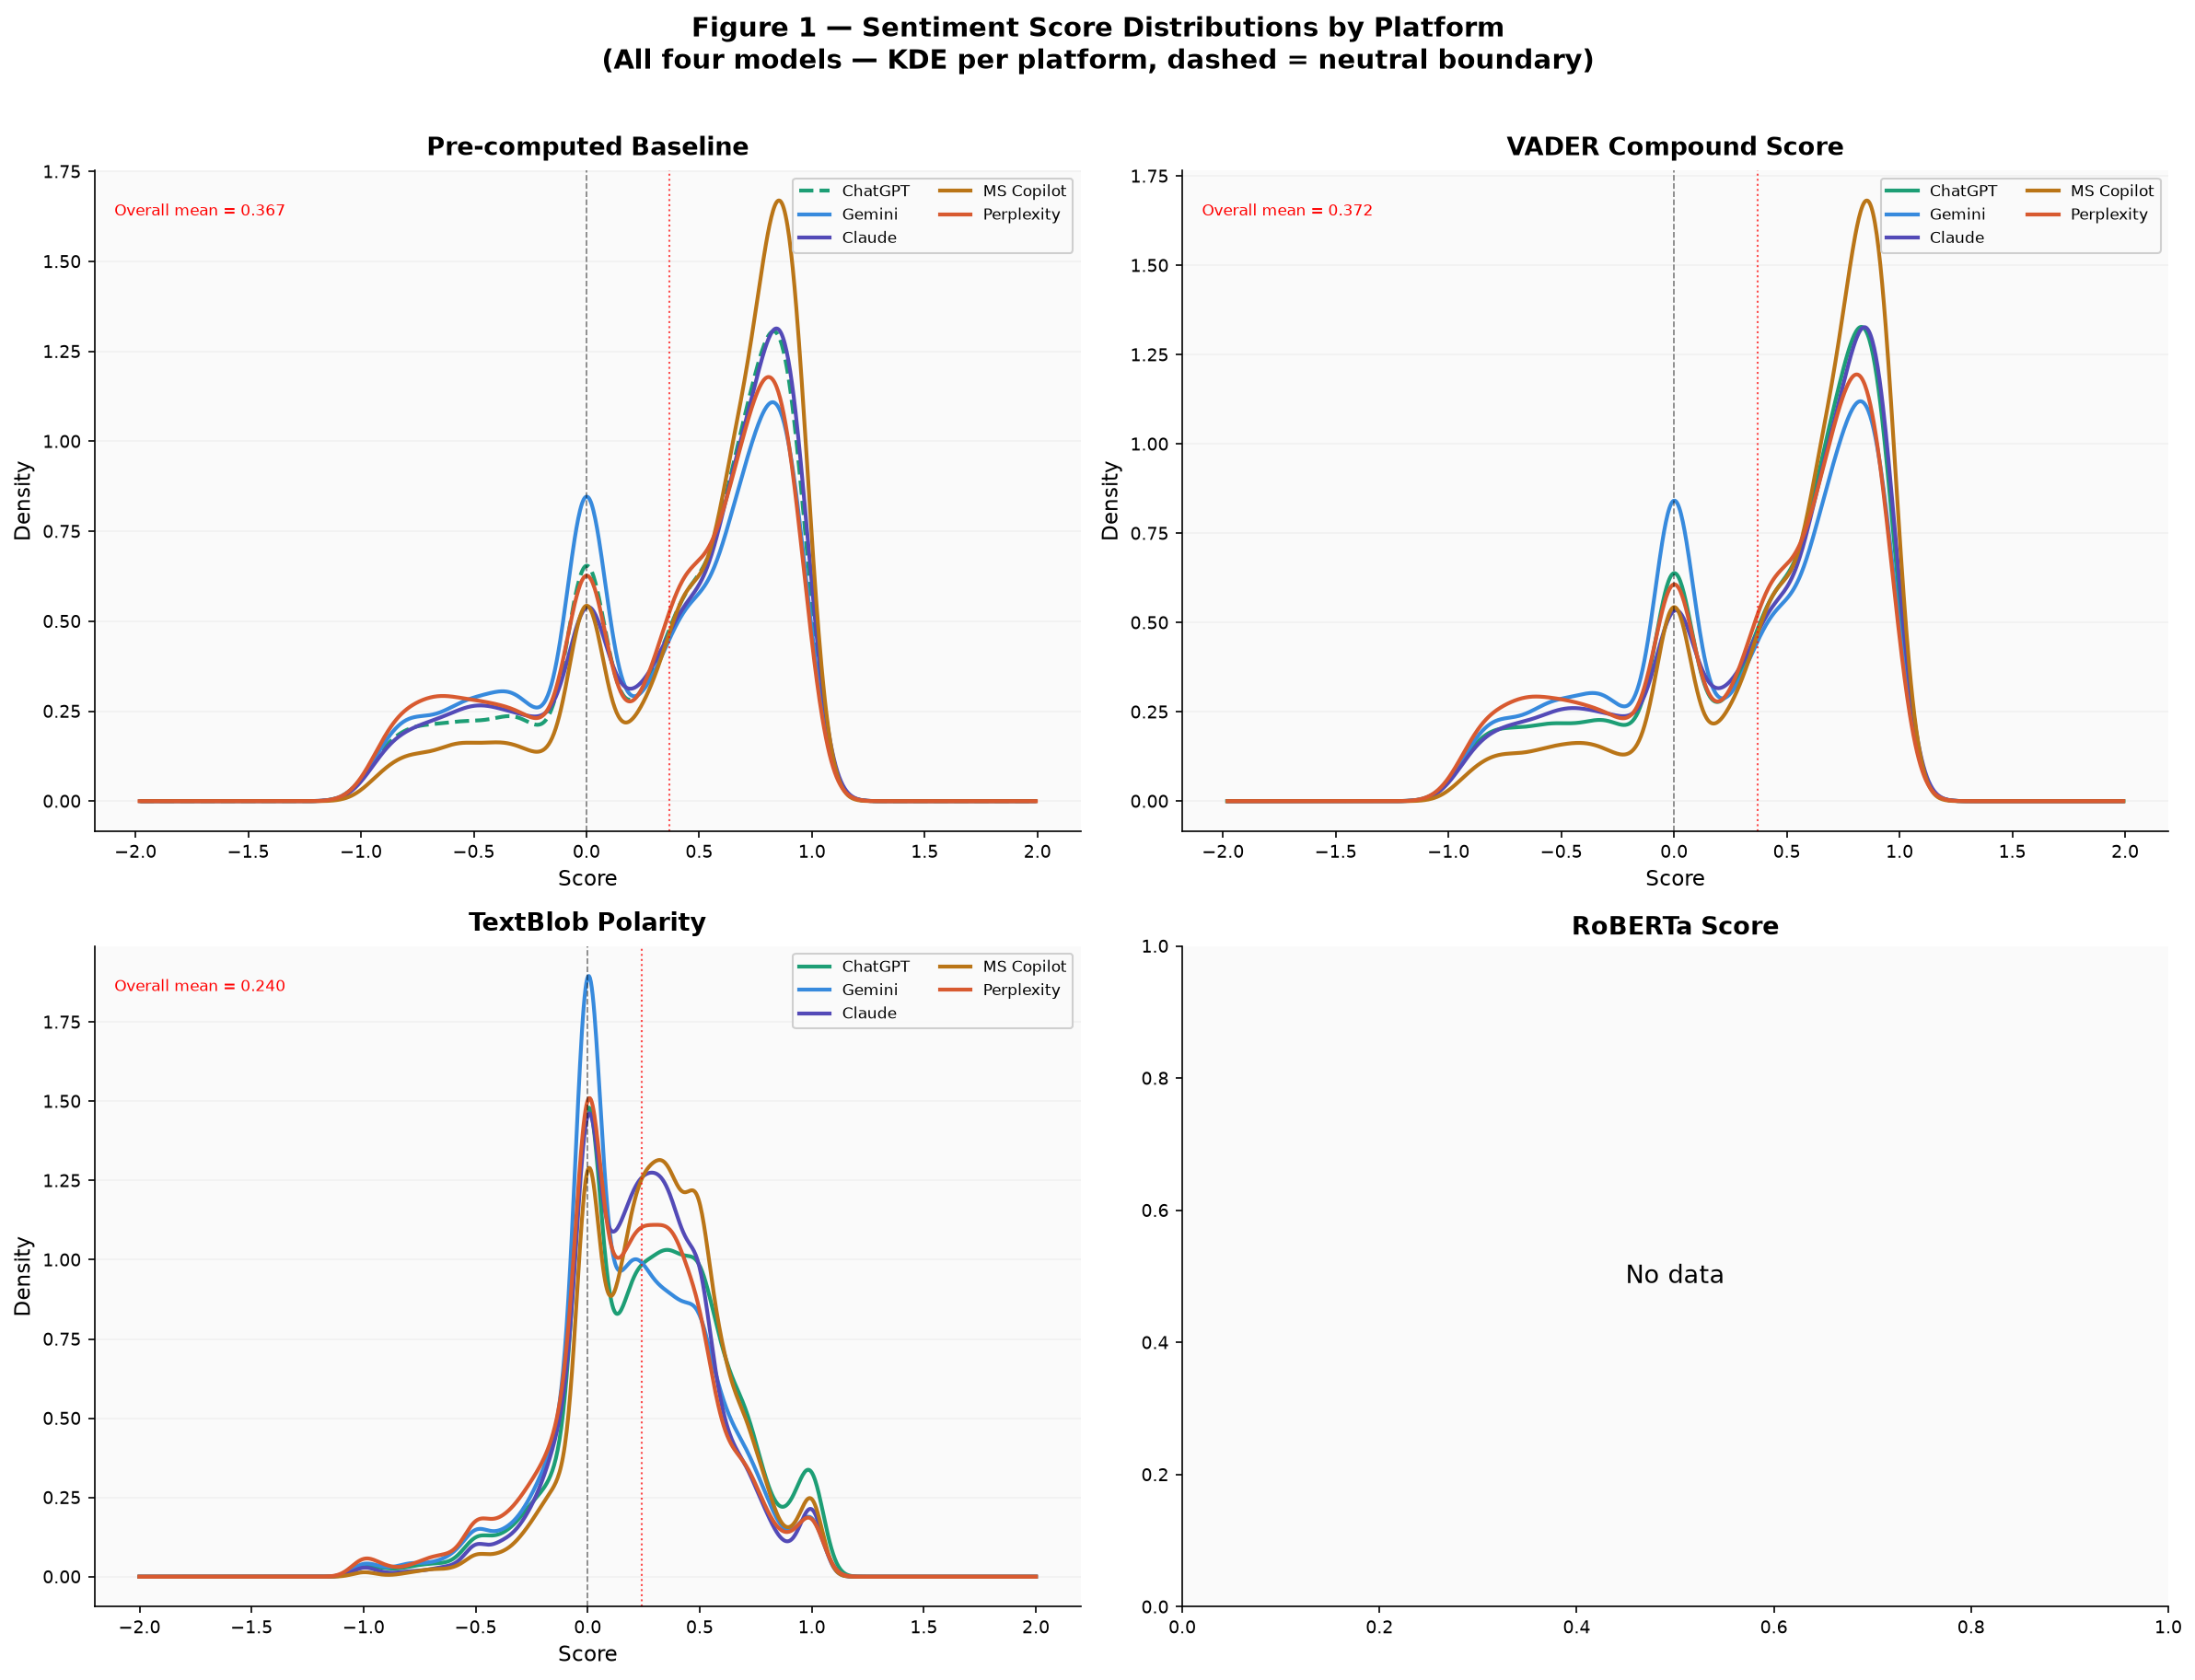

In [16]:
# ── Figure 1: Score distributions — 2×2 KDE grid ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

score_info = [
    ("Sentiment_Polarity", "Pre-computed Baseline",    "dashed", df),
    ("vader_compound",     "VADER Compound Score",     "solid",  df),
    ("tb_polarity",        "TextBlob Polarity",        "solid",  df),
    ("roberta_score",      "RoBERTa Score",            "solid",
     df[df["roberta_processed"]==True] if df["roberta_processed"].any() else df),
]

for ax, (col, title, ls, data) in zip(axes, score_info):
    plot_data = data[col].dropna()
    if len(plot_data) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=13)
        ax.set_title(title, fontweight="bold")
        continue
    for app in APP_ORDER:
        sub = data[data["App"] == app][col].dropna()
        if len(sub) > 10:
            sub.plot(kind="kde", ax=ax, linewidth=2,
                     color=APP_COLORS[app], label=APP_LABELS[app],
                     linestyle=ls if app == APP_ORDER[0] else "solid")
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_title(title, fontweight="bold", pad=8)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.5)
    # Annotate with overall mean
    overall_mean = plot_data.mean()
    ax.axvline(overall_mean, color="red", linestyle=":", linewidth=1, alpha=0.7)
    ax.text(0.02, 0.95, f"Overall mean = {overall_mean:.3f}",
            transform=ax.transAxes, fontsize=8, color="red", va="top")

plt.suptitle("Figure 1 — Sentiment Score Distributions by Platform\n"
             "(All four models — KDE per platform, dashed = neutral boundary)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb03_01_score_distributions.png")
plt.show()

In [17]:
# ── Figure 2: RoBERTa violin plot ──────────────────────────────────────────────
_rdf = df[df["roberta_processed"] == True].copy()

if len(_rdf) == 0:
    print("Skipping Figure 2 — no RoBERTa results.")
else:
    _rdf["Platform"] = _rdf["App"].map(APP_LABELS)
    _p_order         = [APP_LABELS[a] for a in APP_ORDER]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: violin of roberta_score
    sns.violinplot(data=_rdf, x="Platform", y="roberta_score",
                   order=_p_order, palette=PALETTE,
                   inner="quartile", linewidth=0.9, cut=0, ax=axes[0])
    axes[0].axhline(0, color="#E24B4A", linestyle="--",
                    linewidth=1.2, alpha=0.65, label="Neutral (0)")
    axes[0].set_xlabel("Platform")
    axes[0].set_ylabel("RoBERTa Net Score  (positive − negative)")
    axes[0].set_title("RoBERTa Score Distribution\n(inner lines = Q1, median, Q3)",
                      fontweight="bold", pad=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis="y", alpha=0.5)

    # Right: stacked probability bars (mean positive / neutral / negative prob)
    rb_probs = (
        _rdf.groupby("App")[["roberta_positive","roberta_neutral","roberta_negative"]]
            .mean()
            .reindex(APP_ORDER)
    )
    rb_probs.index = _p_order
    _plabels      = [APP_LABELS[a] for a in APP_ORDER]
    _b = np.zeros(len(APP_ORDER))
    for col, color, label in [
        ("roberta_positive", "#1D9E75", "Positive prob."),
        ("roberta_neutral",  "#F5C518", "Neutral prob."),
        ("roberta_negative", "#E24B4A", "Negative prob."),
    ]:
        vals = rb_probs[col].values
        axes[1].bar(_plabels, vals, bottom=_b, color=color,
                    label=label, edgecolor="white", linewidth=0.3, width=0.55)
        for i, (v, b) in enumerate(zip(vals, _b)):
            if v > 0.08:
                axes[1].text(i, b + v/2, f"{v:.2f}", ha="center",
                             va="center", fontsize=9, fontweight="bold", color="white")
        _b += vals
    axes[1].set_ylabel("Mean Probability")
    axes[1].set_title("Mean RoBERTa Class Probabilities\nby Platform",
                      fontweight="bold", pad=10)
    axes[1].legend(fontsize=9, loc="upper right")
    axes[1].grid(axis="y", alpha=0.5)

    plt.suptitle("Figure 2 — RoBERTa Sentiment Analysis by Platform",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_fig("fig_nb03_02_roberta_violin.png")
    plt.show()

Skipping Figure 2 — no RoBERTa results.


  📁  Saved → ../outputs/figures/fig_nb03_03_sentiment_stacked.png


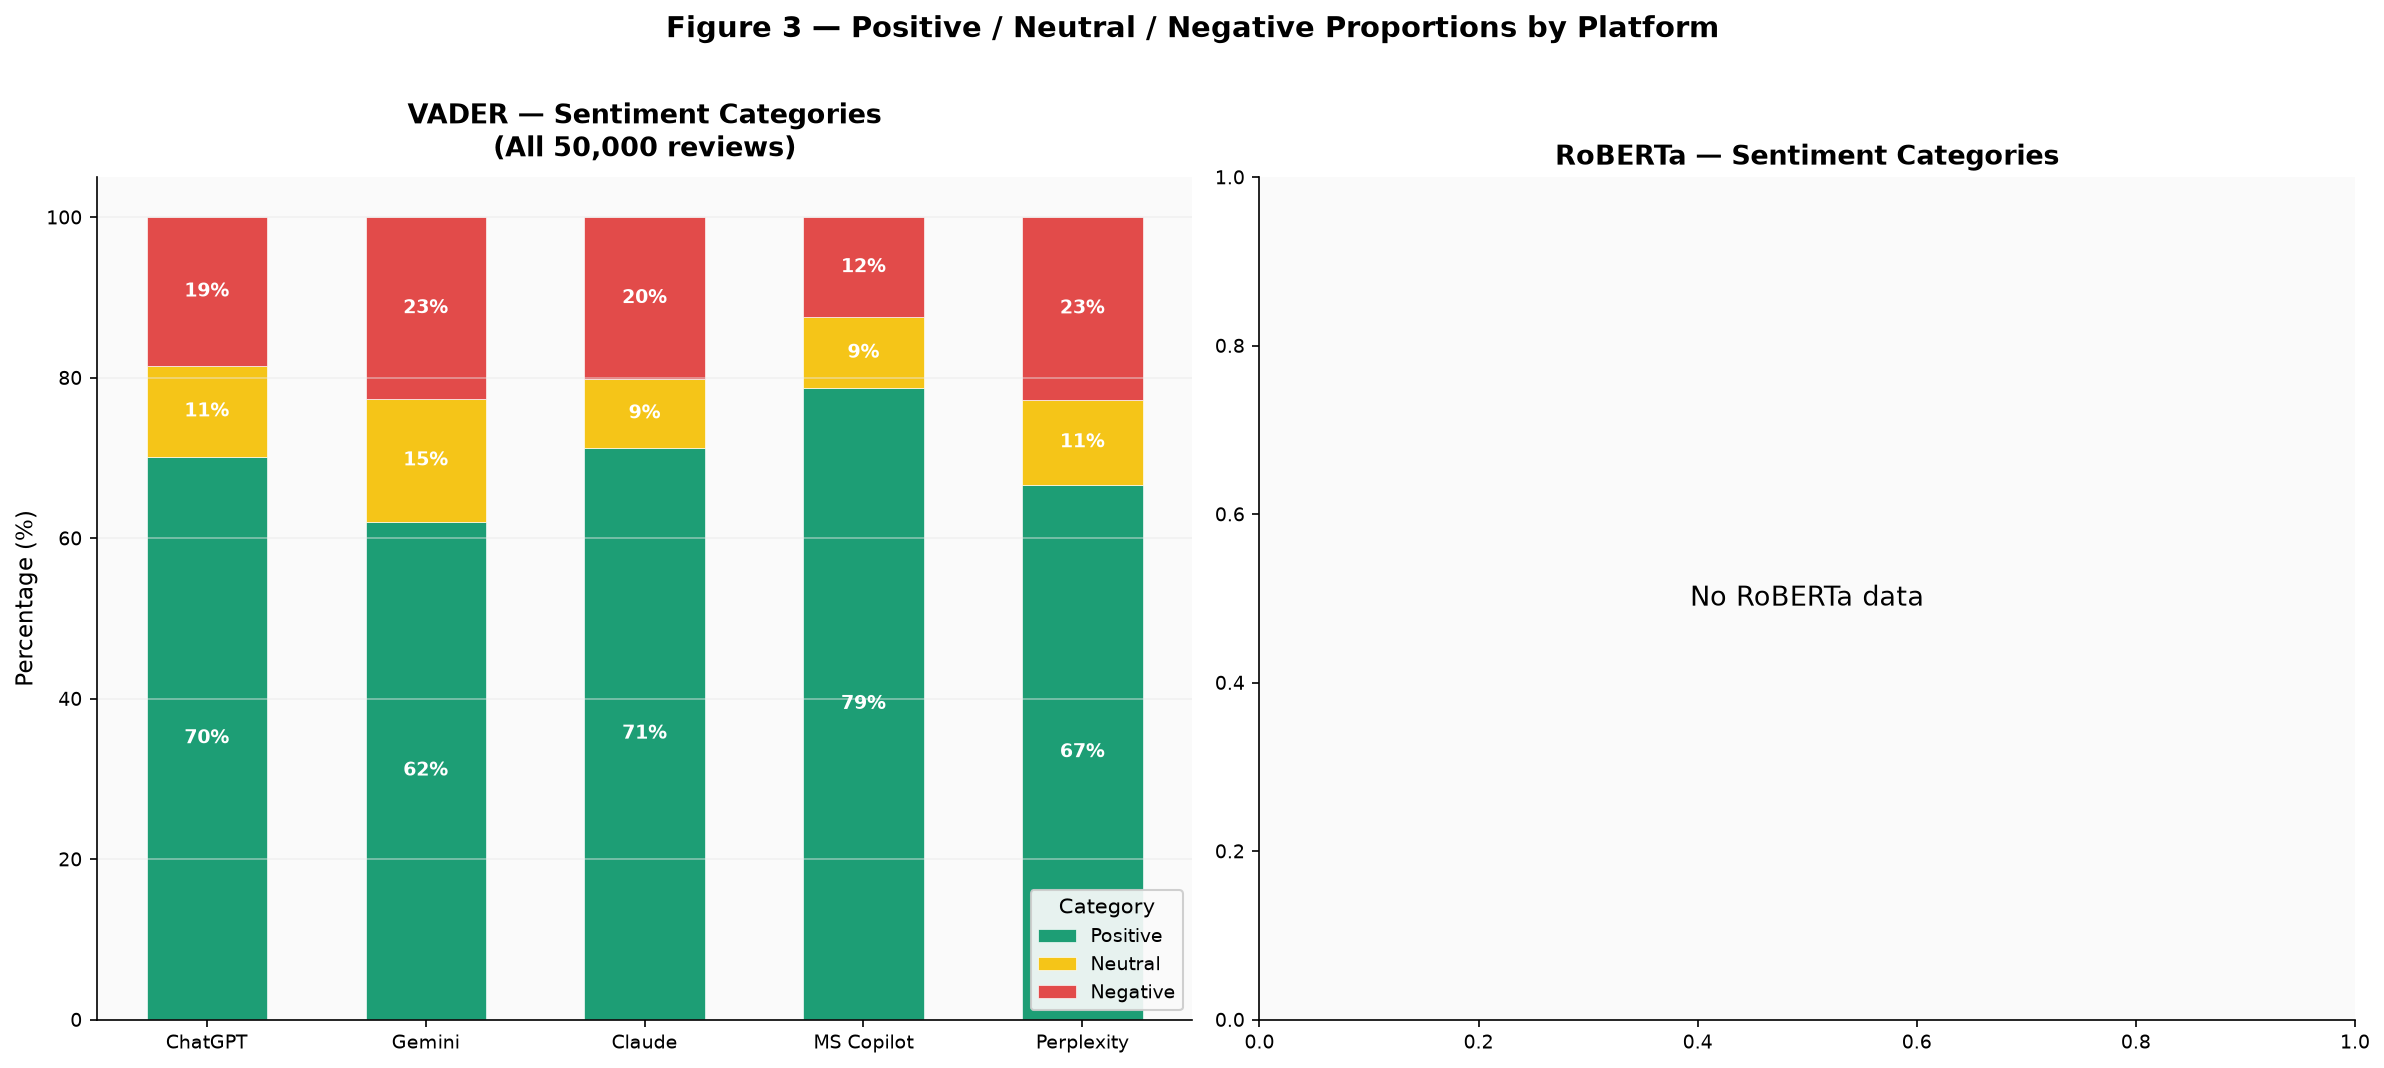

In [18]:
# ── Figure 3: Sentiment category stacked bars ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
_app_display = [APP_LABELS[a] for a in APP_ORDER]

def stacked_sentiment_bars(ax, df_src, label_col, title):
    cats = ["Positive", "Neutral", "Negative"]
    _colors = [CAT_COLORS[c] for c in cats]
    pct = (
        df_src.groupby("App")[label_col]
              .value_counts(normalize=True)
              .mul(100)
              .unstack(fill_value=0)
              .reindex(APP_ORDER)
    )
    # Ensure all category columns exist
    for c in cats:
        if c not in pct.columns:
            pct[c] = 0.0
    pct.index = _app_display
    bottom = np.zeros(len(APP_ORDER))
    for cat, color in zip(cats, _colors):
        vals = pct[cat].values
        ax.bar(_app_display, vals, bottom=bottom, color=color,
               label=cat, edgecolor="white", linewidth=0.3, width=0.55)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 6:
                ax.text(i, b + v/2, f"{v:.0f}%", ha="center",
                        va="center", fontsize=9, fontweight="bold", color="white")
        bottom += vals
    ax.set_ylabel("Percentage (%)")
    ax.set_title(title, fontweight="bold", pad=10)
    ax.legend(title="Category", loc="lower right", fontsize=9)
    ax.grid(axis="y", alpha=0.5)

stacked_sentiment_bars(axes[0], df, "vader_label",
                       "VADER — Sentiment Categories\n(All 50,000 reviews)")

_rdf2 = df[df["roberta_processed"] == True]
if len(_rdf2) > 0:
    stacked_sentiment_bars(axes[1], _rdf2, "roberta_label",
                           "RoBERTa — Sentiment Categories\n(Processed subset)")
else:
    axes[1].text(0.5, 0.5, "No RoBERTa data", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title("RoBERTa — Sentiment Categories", fontweight="bold")

plt.suptitle("Figure 3 — Positive / Neutral / Negative Proportions by Platform",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb03_03_sentiment_stacked.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb03_04_twsi_ranking.png


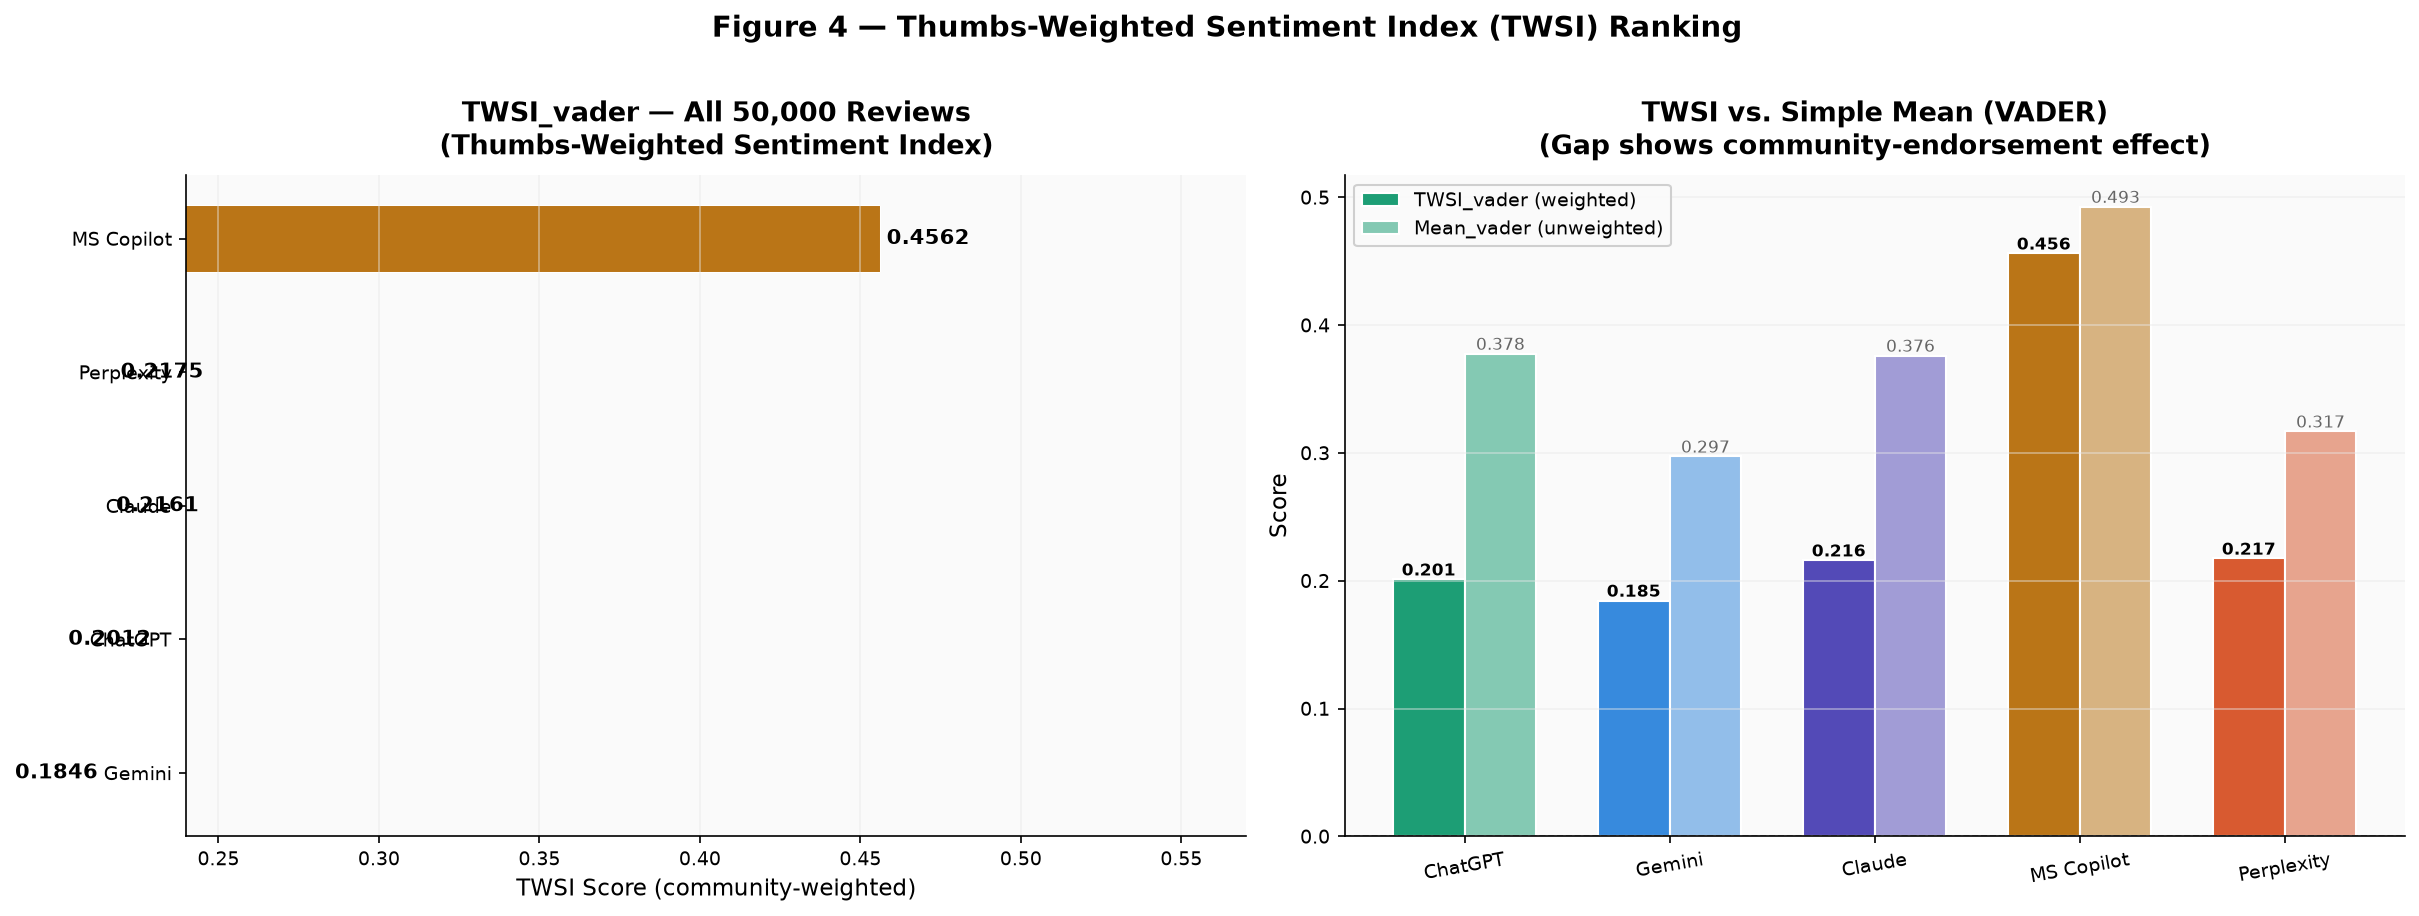

In [19]:
# ── Figure 4: TWSI ranking chart ───────────────────────────────────────────────
_twsi_sorted = twsi_df.sort_values("TWSI_vader", ascending=True)
_apps_sorted = _twsi_sorted.index.tolist()
_lbls_sorted = [APP_LABELS[a] for a in _apps_sorted]
_cols_sorted = [APP_COLORS[a] for a in _apps_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: TWSI_vader (all 50K)
bars = axes[0].barh(_lbls_sorted, _twsi_sorted["TWSI_vader"],
                    color=_cols_sorted, edgecolor="white", linewidth=0.5, height=0.5)
for bar, val in zip(bars, _twsi_sorted["TWSI_vader"]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10, fontweight="bold")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0].set_xlabel("TWSI Score (community-weighted)")
axes[0].set_title("TWSI_vader — All 50,000 Reviews\n(Thumbs-Weighted Sentiment Index)",
                  fontweight="bold", pad=10)
axes[0].set_xlim(_twsi_sorted["TWSI_vader"].min() * 1.3,
                 _twsi_sorted["TWSI_vader"].max() * 1.25)
axes[0].grid(axis="x", alpha=0.5)

# Right: TWSI_vader vs Mean_vader comparison (side-by-side dots)
x = np.arange(len(APP_ORDER))
w = 0.35
_app_d = [APP_LABELS[a] for a in APP_ORDER]
b1 = axes[1].bar(x - w/2, twsi_df.loc[APP_ORDER, "TWSI_vader"], width=w,
                 color=PALETTE, label="TWSI_vader (weighted)", edgecolor="white")
b2 = axes[1].bar(x + w/2, twsi_df.loc[APP_ORDER, "Mean_vader"], width=w,
                 color=[c + "88" for c in PALETTE],
                 label="Mean_vader (unweighted)", edgecolor="white")
for bar, val in zip(b1, twsi_df.loc[APP_ORDER, "TWSI_vader"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")
for bar, val in zip(b2, twsi_df.loc[APP_ORDER, "Mean_vader"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f"{val:.3f}", ha="center", fontsize=8, color="#666666")
axes[1].set_xticks(x)
axes[1].set_xticklabels(_app_d, rotation=10)
axes[1].set_ylabel("Score")
axes[1].set_title("TWSI vs. Simple Mean (VADER)\n(Gap shows community-endorsement effect)",
                  fontweight="bold", pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.5)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

plt.suptitle("Figure 4 — Thumbs-Weighted Sentiment Index (TWSI) Ranking",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb03_04_twsi_ranking.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb03_05_model_agreement.png


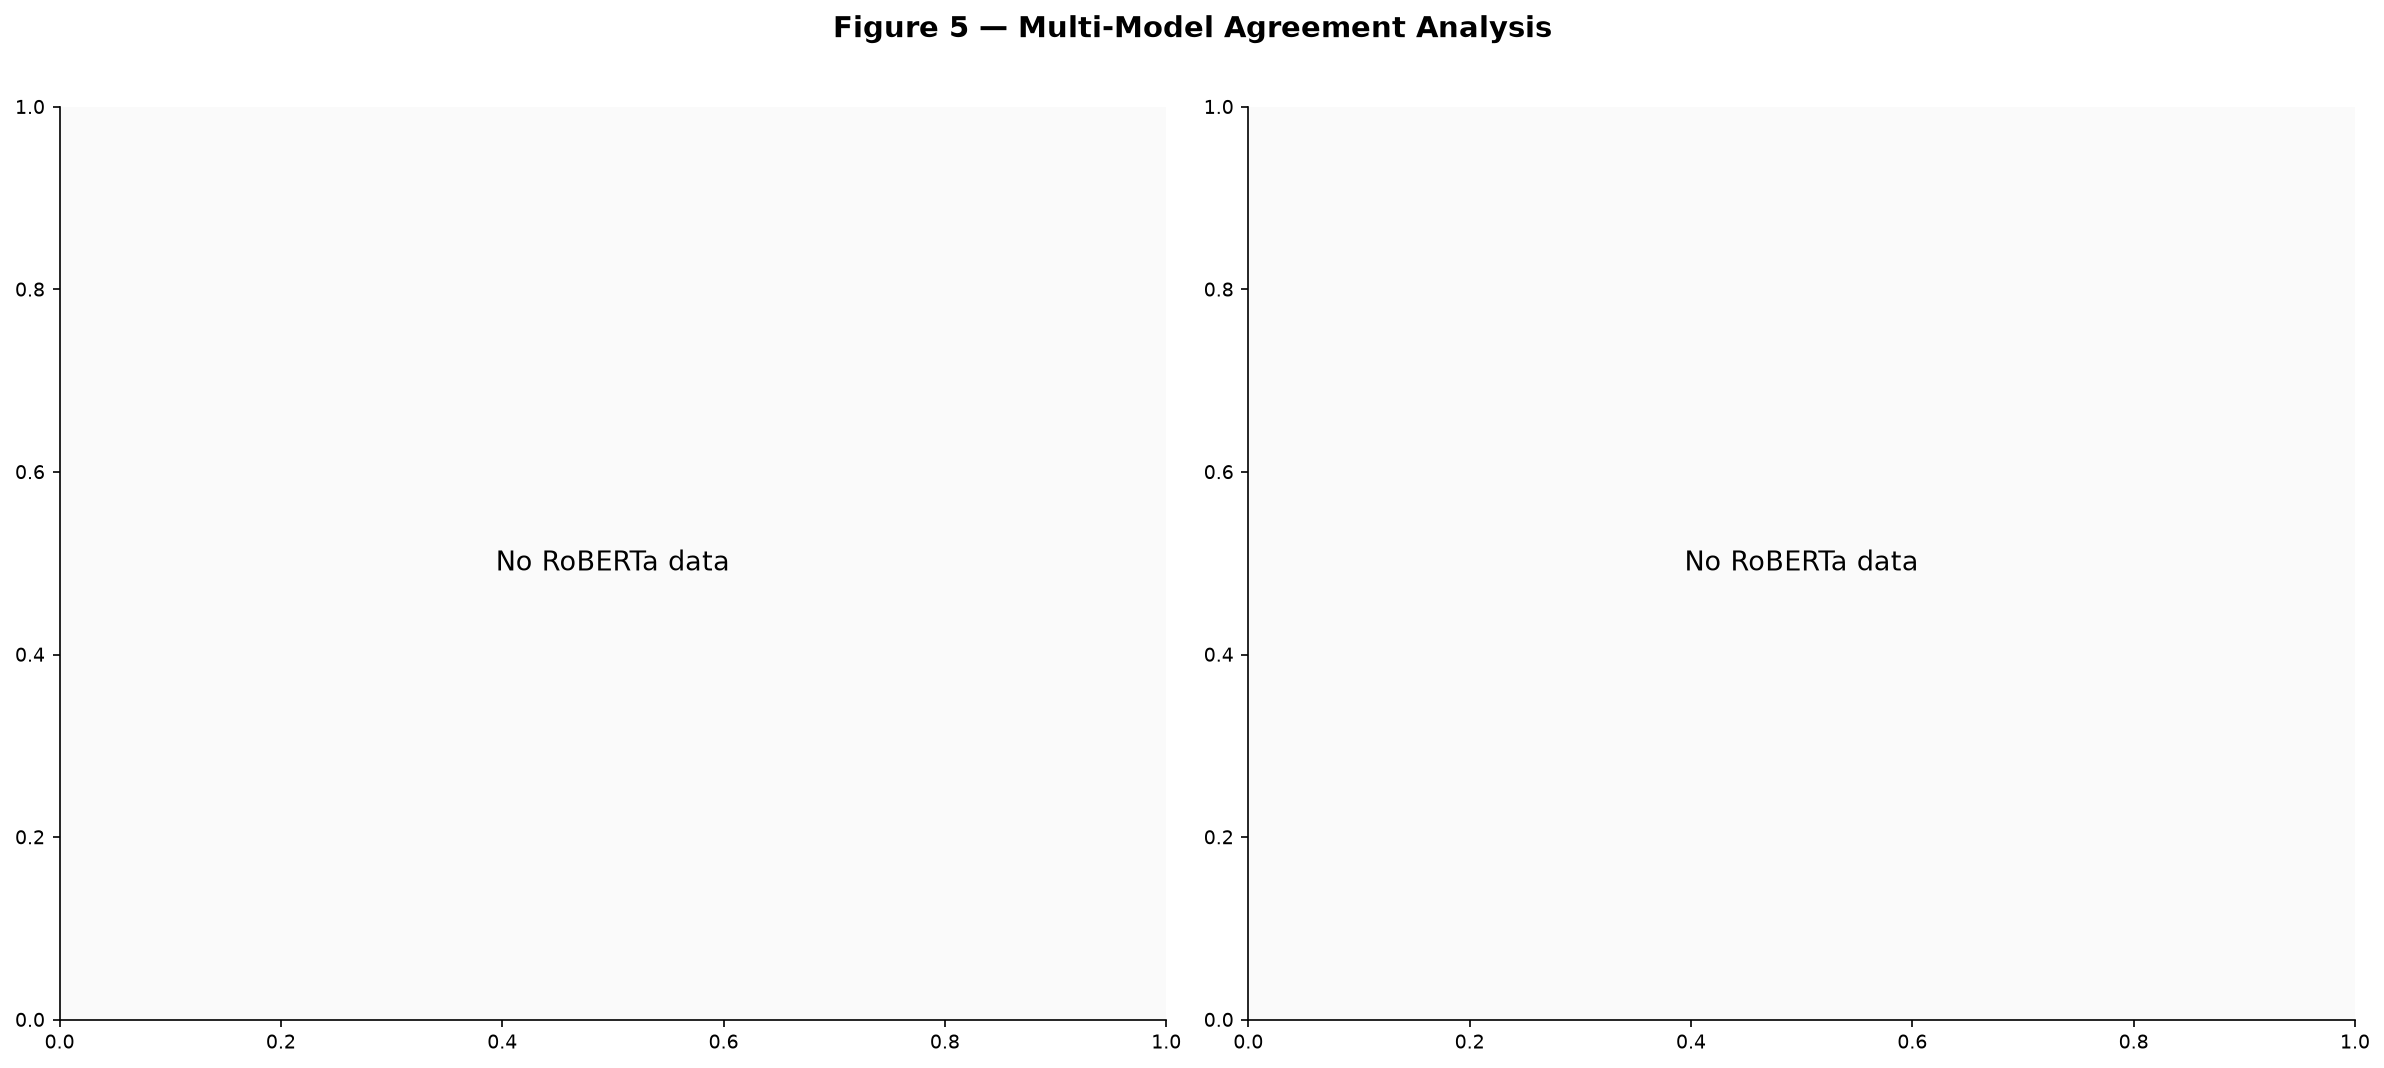

In [20]:
# ── Figure 5: Model agreement heatmap ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_proc5 = df[df["roberta_processed"] == True].copy()

if len(_proc5) == 0:
    axes[0].text(0.5, 0.5, "No RoBERTa data", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=13)
    axes[1].text(0.5, 0.5, "No RoBERTa data", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=13)
else:
    # Left: pairwise label agreement heatmap
    _models = ["vader_label", "tb_label", "roberta_label"]
    _mnames = ["VADER", "TextBlob", "RoBERTa"]
    n_m     = len(_models)
    agree_mat = np.zeros((n_m, n_m))
    for i, m1 in enumerate(_models):
        for j, m2 in enumerate(_models):
            mask = _proc5[m1].notna() & _proc5[m2].notna()
            agree_mat[i, j] = ((_proc5.loc[mask, m1] == _proc5.loc[mask, m2])
                                .mean() * 100)

    agree_df = pd.DataFrame(agree_mat, index=_mnames, columns=_mnames)
    sns.heatmap(agree_df, ax=axes[0], annot=True, fmt=".1f",
                annot_kws={"size": 14, "weight": "bold"},
                cmap="RdYlGn", vmin=50, vmax=100,
                linewidths=1, linecolor="white",
                cbar_kws={"shrink": 0.8, "label": "Agreement %"})
    axes[0].set_title("Pairwise Model Label Agreement (%)\n"
                      "(Diagonal = 100% by definition)",
                      fontweight="bold", pad=10)

    # Right: score correlation heatmap
    _score_c = ["Sentiment_Polarity", "vader_compound",
                "tb_polarity", "roberta_score"]
    _snms    = ["Baseline\nPolarity", "VADER\nCompound",
                "TextBlob\nPolarity", "RoBERTa\nScore"]
    _corr5   = _proc5[_score_c].corr()
    _corr5.index   = _snms
    _corr5.columns = _snms
    _mask5 = np.triu(np.ones_like(_corr5, dtype=bool), k=1)
    sns.heatmap(_corr5, ax=axes[1], mask=_mask5, annot=True, fmt=".3f",
                annot_kws={"size": 12, "weight": "bold"},
                cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                linewidths=0.6, linecolor="white",
                cbar_kws={"shrink": 0.8, "label": "Pearson r"})
    axes[1].set_title("Score Correlation Matrix\n"
                      "(Pearson r — lower triangle)",
                      fontweight="bold", pad=10)

plt.suptitle("Figure 5 — Multi-Model Agreement Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb03_05_model_agreement.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb03_06_score_boxplots.png


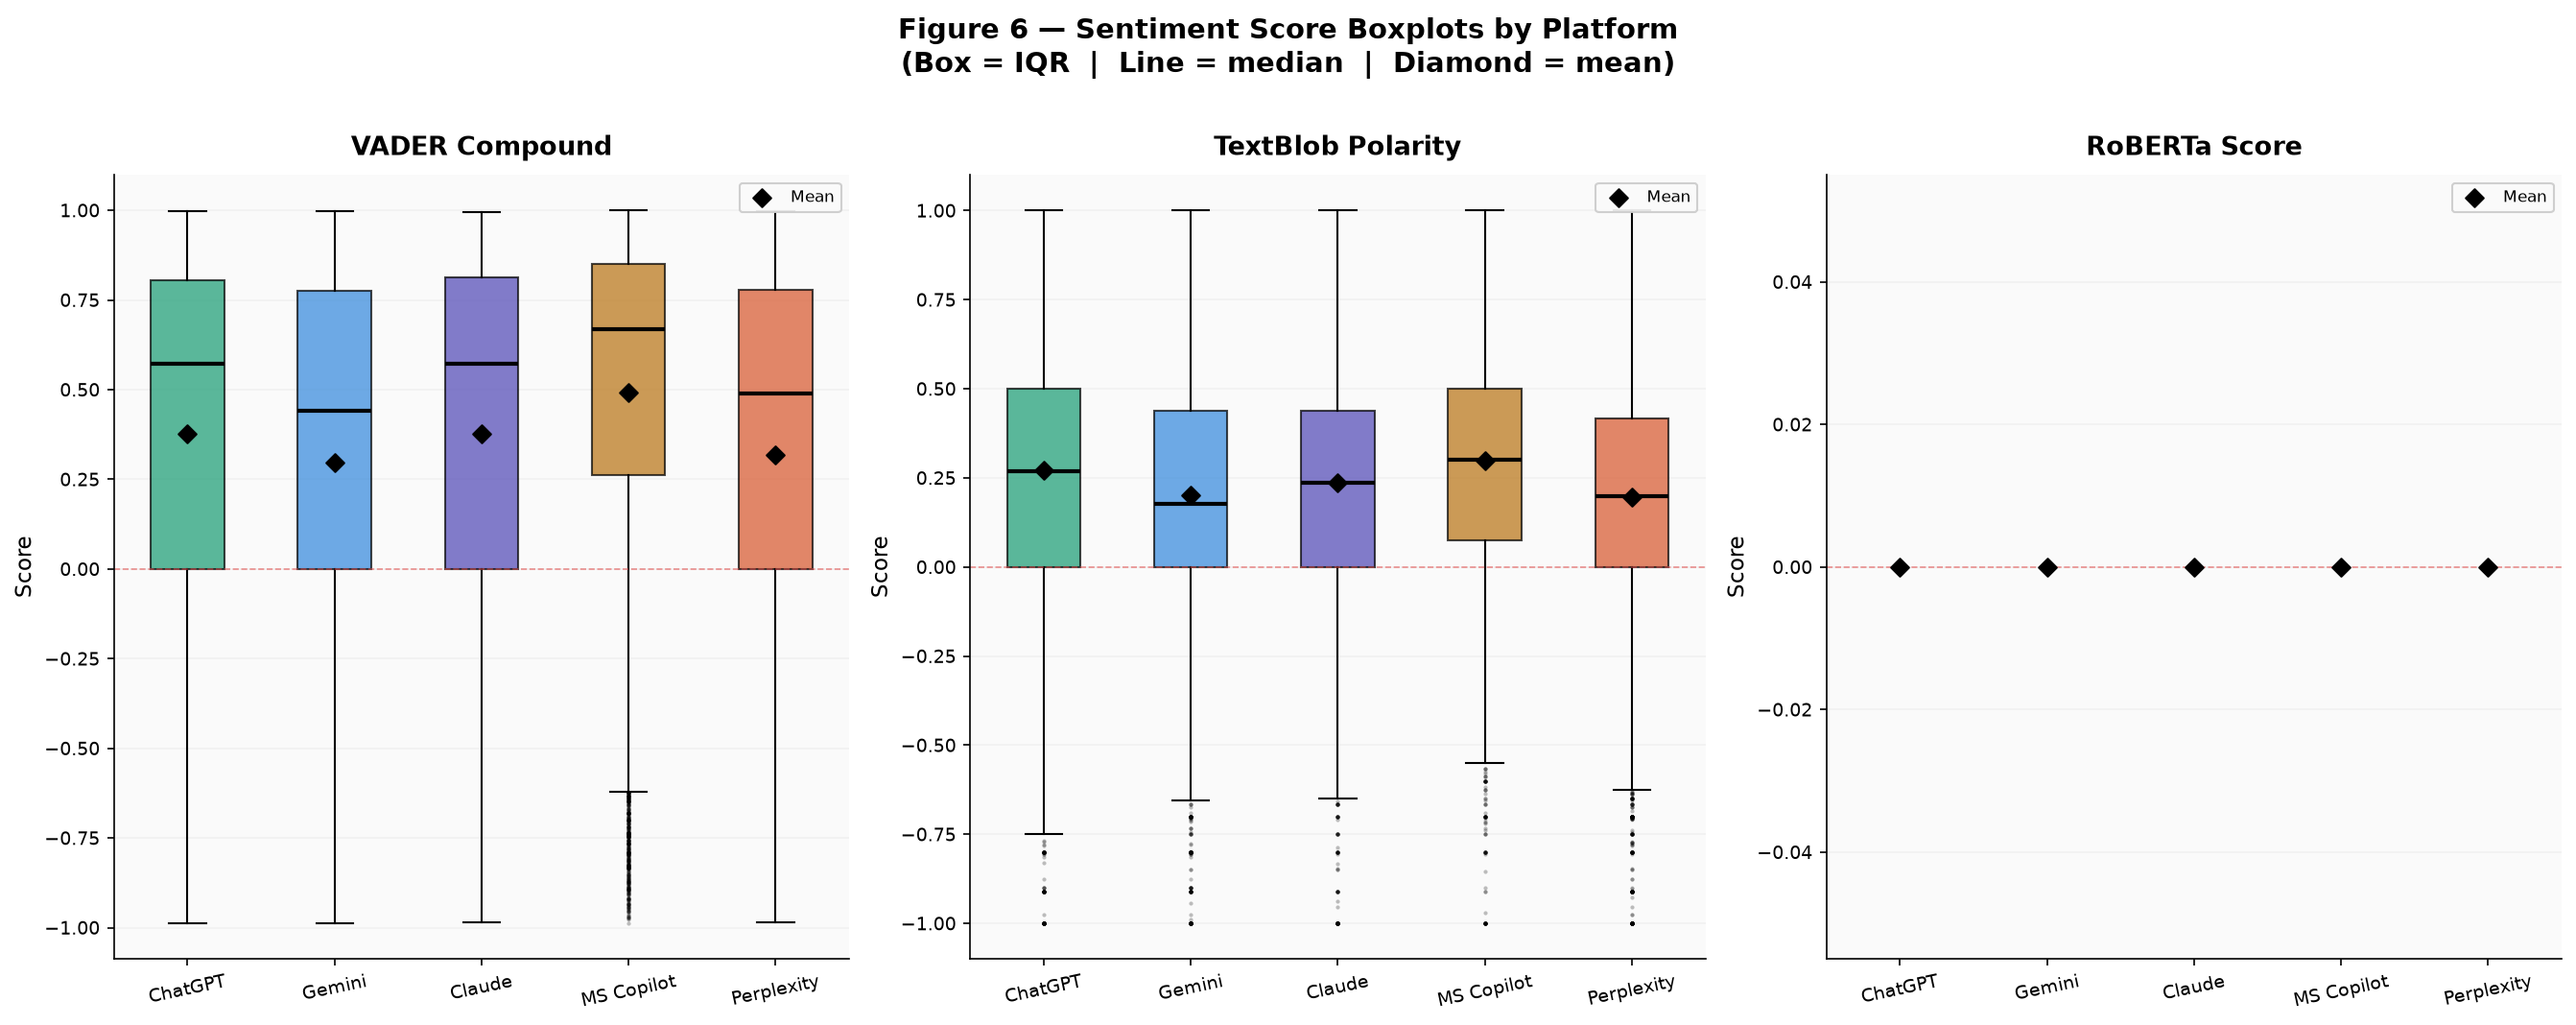

In [21]:
# ── Figure 6: Score boxplots per platform ─────────────────────────────────────
_box_models = [
    ("vader_compound", "VADER Compound",  PALETTE, df),
    ("tb_polarity",    "TextBlob Polarity", PALETTE, df),
    ("roberta_score",  "RoBERTa Score",   PALETTE,
     df[df["roberta_processed"]==True] if df["roberta_processed"].any() else df),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (col, title, colors, src) in zip(axes, _box_models):
    box_data = [src[src["App"]==app][col].dropna().values for app in APP_ORDER]
    bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                    medianprops={"color": "black", "linewidth": 2},
                    flierprops={"marker": ".", "markersize": 2, "alpha": 0.25})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)
    means = [d.mean() if len(d) > 0 else 0 for d in box_data]
    ax.scatter(range(1, len(APP_ORDER)+1), means, color="black",
               zorder=5, marker="D", s=40, label="Mean")
    ax.set_xticks(range(1, len(APP_ORDER)+1))
    ax.set_xticklabels([APP_LABELS[a] for a in APP_ORDER], rotation=12, fontsize=9)
    ax.set_ylabel("Score")
    ax.set_title(title, fontweight="bold", pad=10)
    ax.axhline(0, color="#E24B4A", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.5)

plt.suptitle("Figure 6 — Sentiment Score Boxplots by Platform\n"
             "(Box = IQR  |  Line = median  |  Diamond = mean)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb03_06_score_boxplots.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb03_07_platform_dashboard.png


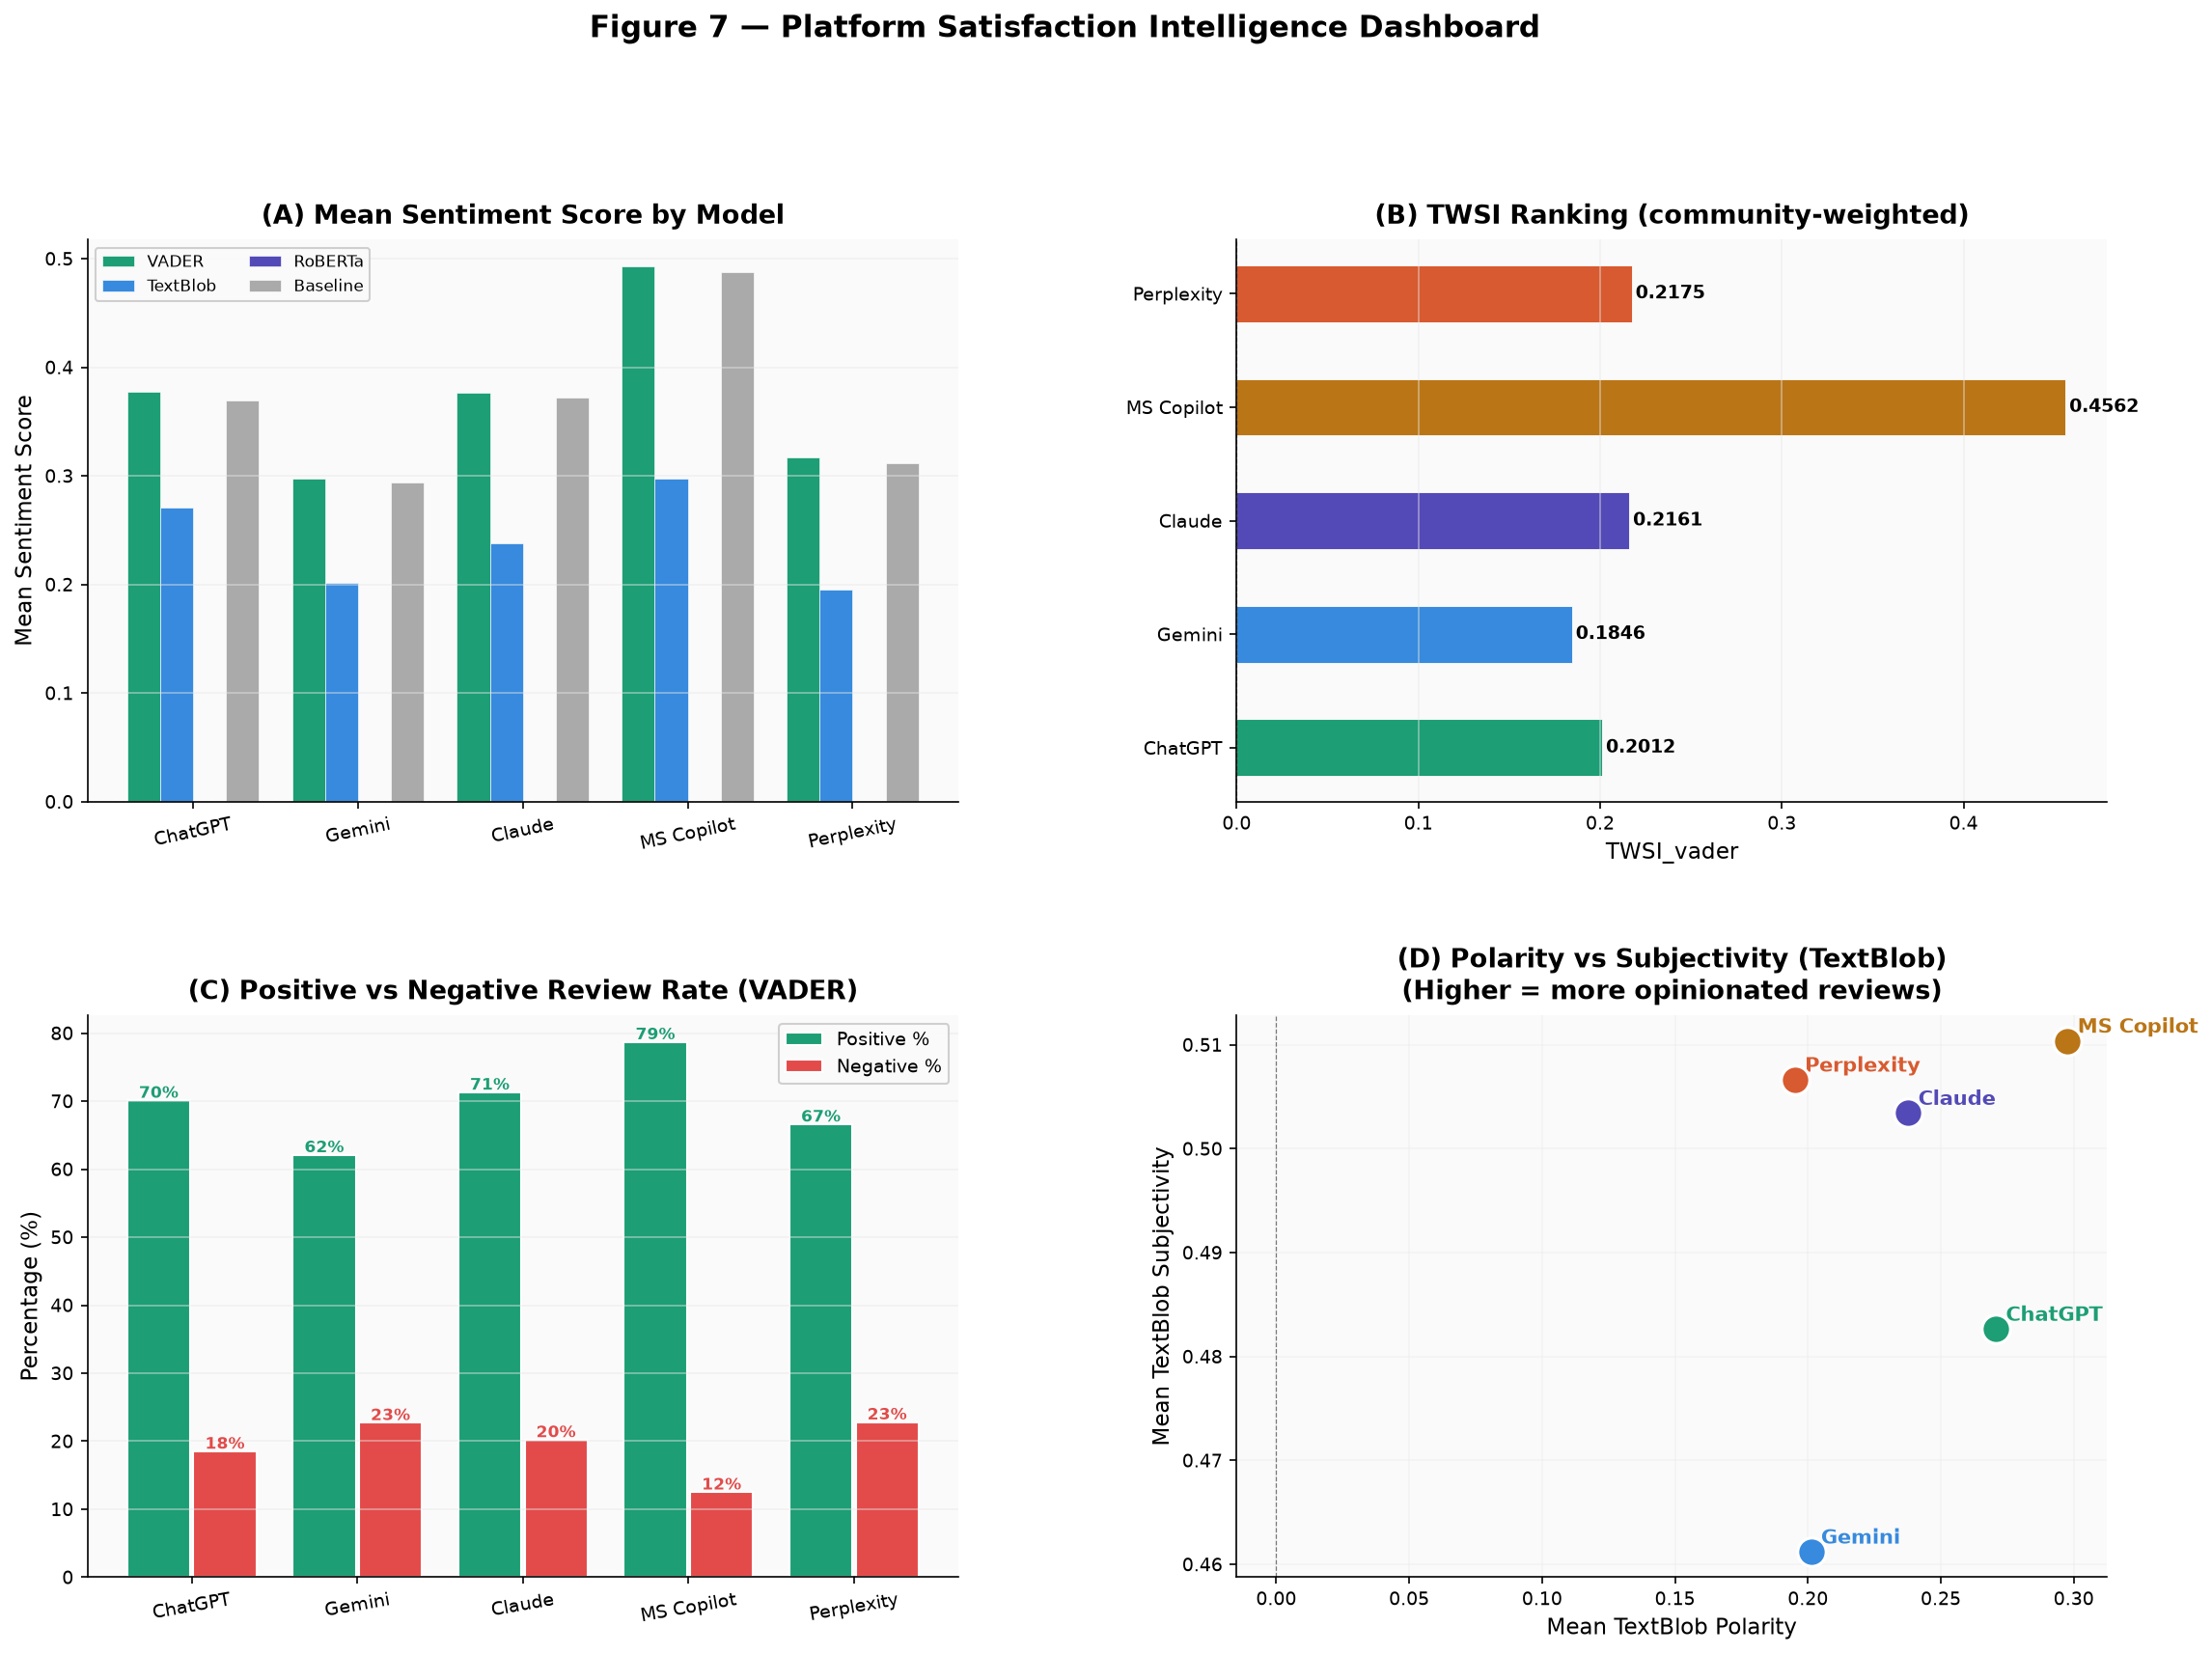

In [22]:
# ── Figure 7: Platform dashboard (4-panel composite) ──────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

_app_d = [APP_LABELS[a] for a in APP_ORDER]

# Panel A: Mean scores — all 4 models
_metrics = {
    "VADER"    : plat_stats_df["VADER mean"].values,
    "TextBlob" : plat_stats_df["TextBlob mean"].values,
    "RoBERTa"  : plat_stats_df["RoBERTa mean"].fillna(0).values,
    "Baseline" : plat_stats_df["Baseline mean"].values,
}
x4 = np.arange(len(APP_ORDER))
_mcolors = ["#1D9E75", "#378ADD", "#534AB7", "#AAAAAA"]
w4 = 0.2
for k, (mname, vals) in enumerate(_metrics.items()):
    offset = (k - 1.5) * w4
    ax1.bar(x4 + offset, vals, width=w4, label=mname,
            color=_mcolors[k], edgecolor="white", linewidth=0.3)
ax1.set_xticks(x4)
ax1.set_xticklabels(_app_d, rotation=12, fontsize=9)
ax1.set_ylabel("Mean Sentiment Score")
ax1.axhline(0, color="black", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.set_title("(A) Mean Sentiment Score by Model", fontweight="bold", pad=8)
ax1.legend(fontsize=8, ncol=2)
ax1.grid(axis="y", alpha=0.5)

# Panel B: TWSI ranking
_twsi_s2 = twsi_df["TWSI_vader"].reindex(APP_ORDER)
bars_b = ax2.barh(_app_d, _twsi_s2.values, color=PALETTE,
                  edgecolor="white", linewidth=0.4, height=0.5)
for bar, val in zip(bars_b, _twsi_s2.values):
    ax2.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax2.axvline(0, color="black", linestyle="--", linewidth=0.6, alpha=0.5)
ax2.set_xlabel("TWSI_vader")
ax2.set_title("(B) TWSI Ranking (community-weighted)", fontweight="bold", pad=8)
ax2.grid(axis="x", alpha=0.5)

# Panel C: % positive (VADER) per platform
_pos_pcts = plat_stats_df["VADER pos %"].values
_neg_pcts = plat_stats_df["VADER neg %"].values
x3c = np.arange(len(APP_ORDER))
ax3.bar(x3c - 0.2, _pos_pcts, width=0.38, color="#1D9E75",
        label="Positive %", edgecolor="white")
ax3.bar(x3c + 0.2, _neg_pcts, width=0.38, color="#E24B4A",
        label="Negative %", edgecolor="white")
for i, (p, n) in enumerate(zip(_pos_pcts, _neg_pcts)):
    ax3.text(i - 0.2, p + 0.4, f"{p:.0f}%", ha="center", fontsize=8, fontweight="bold", color="#1D9E75")
    ax3.text(i + 0.2, n + 0.4, f"{n:.0f}%", ha="center", fontsize=8, fontweight="bold", color="#E24B4A")
ax3.set_xticks(x3c)
ax3.set_xticklabels(_app_d, rotation=10, fontsize=9)
ax3.set_ylabel("Percentage (%)")
ax3.set_title("(C) Positive vs Negative Review Rate (VADER)", fontweight="bold", pad=8)
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.5)

# Panel D: TextBlob subjectivity vs polarity scatter
for app in APP_ORDER:
    sub_d = df[df["App"] == app]
    ax4.scatter(sub_d["tb_polarity"].mean(),
                sub_d["tb_subjectivity"].mean(),
                color=APP_COLORS[app], s=200, zorder=5,
                edgecolors="white", linewidth=1.5)
    ax4.annotate(APP_LABELS[app],
                 xy=(sub_d["tb_polarity"].mean(),
                     sub_d["tb_subjectivity"].mean()),
                 xytext=(5, 4), textcoords="offset points",
                 fontsize=10, color=APP_COLORS[app], fontweight="bold")
ax4.set_xlabel("Mean TextBlob Polarity")
ax4.set_ylabel("Mean TextBlob Subjectivity")
ax4.set_title("(D) Polarity vs Subjectivity (TextBlob)\n"
              "(Higher = more opinionated reviews)", fontweight="bold", pad=8)
ax4.grid(True, alpha=0.4)
ax4.axvline(0, color="black", linestyle="--", linewidth=0.6, alpha=0.5)

plt.suptitle("Figure 7 — Platform Satisfaction Intelligence Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
save_fig("fig_nb03_07_platform_dashboard.png")
plt.show()

---
## 💾 Section 10 — Export Results

Save the fully enriched dataset for use by Notebooks 04 (Topic Modeling) and 05 (Migration Analysis).

In [23]:
print("Saving enriched dataset...")
_t0 = time.time()

# ── Parquet ────────────────────────────────────────────────────────────────────
df.to_parquet(OUTPUT_PARQ, index=False, engine="pyarrow")
_psz = os.path.getsize(OUTPUT_PARQ) / 1e6
print(f"  ✅  {OUTPUT_PARQ}")
print(f"      {_psz:.1f} MB  |  {time.time()-_t0:.1f}s")

# ── CSV ────────────────────────────────────────────────────────────────────────
_t1 = time.time()
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
_csz = os.path.getsize(OUTPUT_CSV) / 1e6
print(f"  ✅  {OUTPUT_CSV}")
print(f"      {_csz:.1f} MB  |  {time.time()-_t1:.1f}s")

# ── Round-trip verify ─────────────────────────────────────────────────────────
_check = pd.read_parquet(OUTPUT_PARQ)
assert _check.shape == df.shape, "Shape mismatch after reload!"
print(f"\n✅  Round-trip verified: {_check.shape[0]:,} rows × {_check.shape[1]} columns")
print()

# ── New columns manifest ──────────────────────────────────────────────────────
new_cols = [c for c in df.columns if c not in [
    "App","Review_Date","Star_Rating","Review_Text","Word_Count",
    "Review_Length_Chars","Thumbs_Up_Count","App_Version",
    "Sentiment_Polarity","Review_Theme","review_text_clean",
    "is_duplicate_text","review_length_chars","review_length_words",
    "sentence_count","avg_word_length","exclamation_count","question_count",
    "uppercase_ratio","thumbs_log","review_year","review_month","review_day",
    "review_weekday","review_weekday_name","is_positive_review",
    "is_negative_review","is_neutral_review","is_influential_review",
    "review_text_nlp"
]]
print(f"New columns added by NB03 ({len(new_cols)}):")
for c in new_cols:
    nn = df[c].notnull().sum()
    print(f"  {c:<28}  non-null={nn:,}")

Saving enriched dataset...
  ✅  ../data/processed/reviews_sentiment.parquet
      14.1 MB  |  0.2s
  ✅  ../data/processed/reviews_sentiment.csv
      29.5 MB  |  1.5s

✅  Round-trip verified: 50,000 rows × 44 columns

New columns added by NB03 (14):
  vader_compound                non-null=50,000
  vader_positive                non-null=50,000
  vader_negative                non-null=50,000
  vader_neutral                 non-null=50,000
  vader_label                   non-null=50,000
  tb_polarity                   non-null=50,000
  tb_subjectivity               non-null=50,000
  tb_label                      non-null=50,000
  roberta_negative              non-null=0
  roberta_neutral               non-null=0
  roberta_positive              non-null=0
  roberta_score                 non-null=0
  roberta_label                 non-null=0
  roberta_processed             non-null=50,000


---
## 📋 Section 11 — Executive Summary

Auto-generated findings for the final report methodology and results section.

In [24]:
print("=" * 70)
print("  SENTIMENT ANALYSIS EXECUTIVE SUMMARY — SENTIMENTCOMPASS NB03")
print("=" * 70)

# ── Best / Worst platforms ────────────────────────────────────────────────────
_vbest   = twsi_df["TWSI_vader"].idxmax()
_vworst  = twsi_df["TWSI_vader"].idxmin()

print()
print("── PLATFORM RANKINGS ────────────────────────────────────────────────────")
print()
print("  TWSI_vader ranking (community-endorsed satisfaction, all 50K reviews):")
for rank, (app, row) in enumerate(
        twsi_df.sort_values("TWSI_vader", ascending=False).iterrows(), 1):
    marker = " 🏆" if rank == 1 else (" 📉" if rank == 5 else "")
    print(f"    #{rank}  {APP_LABELS[app]:<14}  TWSI={row['TWSI_vader']:.4f}  "
          f"Mean_vader={row['Mean_vader']:.4f}{marker}")

print()
print(f"  Most satisfied platform  : {APP_LABELS[_vbest]}")
print(f"  Least satisfied platform : {APP_LABELS[_vworst]}")
print(f"  Satisfaction gap (TWSI)  : "
      f"{twsi_df.loc[_vbest,'TWSI_vader'] - twsi_df.loc[_vworst,'TWSI_vader']:.4f}")

# ── VADER insights ────────────────────────────────────────────────────────────
print()
print("── VADER FINDINGS (all 50,000 reviews) ──────────────────────────────────")
_vc = df["vader_label"].value_counts()
for lbl in ["Positive", "Neutral", "Negative"]:
    n = _vc.get(lbl, 0)
    print(f"  {lbl:<10}: {n:>7,}  ({n/len(df)*100:.1f}%)")
_corr_vs2, _ = stats.pearsonr(df["Star_Rating"], df["vader_compound"])
print(f"  Pearson r vs Star_Rating : {_corr_vs2:.4f}")
print(f"  Highest positive % : {APP_LABELS[df.groupby('App')['vader_label'].apply(lambda x: (x=='Positive').mean()).idxmax()]}")
print(f"  Highest negative % : {APP_LABELS[df.groupby('App')['vader_label'].apply(lambda x: (x=='Negative').mean()).idxmax()]}")

# ── TextBlob insights ─────────────────────────────────────────────────────────
print()
print("── TEXTBLOB FINDINGS (all 50,000 reviews) ───────────────────────────────")
_tc = df["tb_label"].value_counts()
for lbl in ["Positive", "Neutral", "Negative"]:
    n = _tc.get(lbl, 0)
    print(f"  {lbl:<10}: {n:>7,}  ({n/len(df)*100:.1f}%)")
_most_subj = df.groupby("App")["tb_subjectivity"].mean().idxmax()
_least_subj = df.groupby("App")["tb_subjectivity"].mean().idxmin()
print(f"  Most opinionated reviews : {APP_LABELS[_most_subj]}")
print(f"  Most factual reviews     : {APP_LABELS[_least_subj]}")

# ── RoBERTa insights ──────────────────────────────────────────────────────────
_proc_r = df[df["roberta_processed"] == True]
print()
print(f"── ROBERTA FINDINGS ({len(_proc_r):,} processed reviews) ─────────────────────────")
if len(_proc_r) > 0:
    _rc = _proc_r["roberta_label"].value_counts()
    for lbl in ["Positive", "Neutral", "Negative"]:
        n = _rc.get(lbl, 0)
        print(f"  {lbl:<10}: {n:>7,}  ({n/len(_proc_r)*100:.1f}%)")
    _rbest  = _proc_r.groupby("App")["roberta_score"].mean().idxmax()
    _rworst = _proc_r.groupby("App")["roberta_score"].mean().idxmin()
    print(f"  Highest RoBERTa score  : {APP_LABELS[_rbest]}")
    print(f"  Lowest  RoBERTa score  : {APP_LABELS[_rworst]}")
else:
    print("  No RoBERTa results available.")

# ── Model agreement ───────────────────────────────────────────────────────────
print()
print("── MODEL AGREEMENT ──────────────────────────────────────────────────────")
if len(_proc_r) > 0:
    _3agree = df.loc[df["roberta_processed"]==True, "model_agreement"].mean() * 100
    print(f"  Full 3-model agreement rate : {_3agree:.1f}%")
    _vr_agree = ((_proc_r["vader_label"] == _proc_r["roberta_label"])
                 .mean() * 100)
    _tb_agree = ((_proc_r["tb_label"] == _proc_r["roberta_label"])
                 .mean() * 100)
    print(f"  VADER vs RoBERTa agreement  : {_vr_agree:.1f}%")
    print(f"  TextBlob vs RoBERTa agreement: {_tb_agree:.1f}%")
    print(f"  → RoBERTa is the most nuanced model and is used as primary signal.")
else:
    _vt_agree = ((df["vader_label"] == df["tb_label"]).mean() * 100)
    print(f"  VADER vs TextBlob agreement : {_vt_agree:.1f}%")

# ── TWSI insight ──────────────────────────────────────────────────────────────
print()
print("── TWSI INSIGHT ─────────────────────────────────────────────────────────")
twsi_gap   = twsi_df.loc[_vbest, "TWSI_vader"] - twsi_df.loc[_vbest, "Mean_vader"]
twsi_g_wst = twsi_df.loc[_vworst, "TWSI_vader"] - twsi_df.loc[_vworst, "Mean_vader"]
print(f"  {APP_LABELS[_vbest]}: TWSI ({twsi_df.loc[_vbest,'TWSI_vader']:.4f}) "
      f"vs Mean ({twsi_df.loc[_vbest,'Mean_vader']:.4f})  "
      f"delta={twsi_gap:+.4f}")
print(f"  {APP_LABELS[_vworst]}: TWSI ({twsi_df.loc[_vworst,'TWSI_vader']:.4f}) "
      f"vs Mean ({twsi_df.loc[_vworst,'Mean_vader']:.4f})  "
      f"delta={twsi_g_wst:+.4f}")
print(f"  → Positive delta = community endorses positive reviews more than negative ones.")
print(f"  → Negative delta = highly-endorsed reviews skew negative (vocal dissatisfied users).")

# ── Files saved ───────────────────────────────────────────────────────────────
print()
print("── OUTPUT FILES ─────────────────────────────────────────────────────────")
for fpath in [OUTPUT_PARQ, OUTPUT_CSV]:
    sz = os.path.getsize(fpath) / 1e6
    print(f"  ✅  {os.path.basename(fpath)}  ({sz:.1f} MB)")
_figs = [f"fig_nb03_0{i+1}_{n}.png" for i, n in enumerate(
    ["score_distributions","roberta_violin","sentiment_stacked",
     "twsi_ranking","model_agreement","score_boxplots","platform_dashboard"])]
for f in _figs:
    p = os.path.join(FIGURES_DIR, f)
    exists = "✅" if os.path.exists(p) else "❌"
    print(f"  {exists}  {f}")

print()
print("=" * 70)
print("  ▶  Next: run 04_topic_modeling.ipynb")
print("=" * 70)

  SENTIMENT ANALYSIS EXECUTIVE SUMMARY — SENTIMENTCOMPASS NB03

── PLATFORM RANKINGS ────────────────────────────────────────────────────

  TWSI_vader ranking (community-endorsed satisfaction, all 50K reviews):
    #1  MS Copilot      TWSI=0.4562  Mean_vader=0.4928 🏆
    #2  Perplexity      TWSI=0.2175  Mean_vader=0.3170
    #3  Claude          TWSI=0.2161  Mean_vader=0.3763
    #4  ChatGPT         TWSI=0.2012  Mean_vader=0.3778
    #5  Gemini          TWSI=0.1846  Mean_vader=0.2974 📉

  Most satisfied platform  : MS Copilot
  Least satisfied platform : Gemini
  Satisfaction gap (TWSI)  : 0.2716

── VADER FINDINGS (all 50,000 reviews) ──────────────────────────────────
  Positive  :  34,874  (69.7%)
  Neutral   :   5,465  (10.9%)
  Negative  :   9,661  (19.3%)
  Pearson r vs Star_Rating : 0.6189
  Highest positive % : MS Copilot
  Highest negative % : Perplexity

── TEXTBLOB FINDINGS (all 50,000 reviews) ───────────────────────────────
  Positive  :  32,421  (64.8%)
  Neutral   :  11,

---
## 📌 Handoff to Notebooks 04 & 05

| Column | Produced here | Used by |
|--------|-------------|---------|
| `vader_compound` | ✅ | NB05 (migration context) |
| `vader_label` | ✅ | Dashboard filter, NB05 |
| `tb_polarity` | ✅ | Model comparison, Dashboard |
| `tb_subjectivity` | ✅ | Dashboard subjectivity panel |
| `roberta_score` | ✅ | TWSI_roberta, NB05 enriched ranking |
| `roberta_label` | ✅ | NB05 platform-level sentiment |
| `roberta_processed` | ✅ | Filter mask for downstream |
| `ensemble_score` | ✅ | Dashboard primary score (where available) |
| `model_agreement` | ✅ | Dashboard confidence indicator |

**▶ Proceed to `04_topic_modeling.ipynb`** — LDA · BERTopic · Topic Discovery